# Анализ вакансий сайта hh.ru

Нам предоставлены подборки вакансий с сайта hh.ru на должность аналитик данных и специалист data science.

В данных у нас есть id вакансии, ссылка на сайт с данной вакансией, название должности, компания-работодатель, отдел, в который требуется специалист, город размещения вакансии, описание самой вакансии, ключевые навыки, которыми должен обладать претендент, уровень заработной платы.

**Цель нашей работы:** выяснить какие есть различия в требованиях в вакансиях аналитика данных и специалиста data-science.

Для реализации поставленной цели мы выполним следующие задачи:

* предобработка данных: проверим полученные данные на  дубликаты и пропуски, при необходимости заполним их;
* анализ даннных: проверим нет ли выбросов в данных, добавим при необходимости новые признаки для анализа;
* определим какой уровень опыта требуется, какова доля вакансий по уровню требуемого опыта (грейда);
* определим лучших работодателей по количеству вакансий, уровню заработной платы, требований к навыкам и умениям;
* определим какие навыки чаще всего требуются при приеме на работу;
* определим наиболее выгодные вакансии в сравнении с уровнем заработной платы по России;
* рассчитаем помесячную динамику количества вакансий.

In [3]:
# загружаем нужные модули
import pandas as pd
import requests
from urllib.parse import urlencode
import os
import zipfile
from io import BytesIO
import calendar
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

In [4]:
# служебная строка для вывода всех столбцов и строк
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Получение данных

Есть два варианта загрузки данных:
1. загрузка с Яндекс-диска
2. загрузка с локального диска

1. Загрузим данные с Яндекс-диска, для этого напишем две функции, одна будет скачивать файл и сохранять в архив, а вторая читать Excel файлы из архива.

In [8]:
# def get_zip_file(base_url, public_key, path_to_save):

#     """ напишем функцию, котороя будет скачивать файлы с сайтов и сохранять их в виде zip архива
#     """
#     # Получаем загрузочную ссылку
#     final_url = base_url + urlencode(dict(public_key=public_key))
#     response = requests.get(final_url)
#     download_url = response.json()['href']

#     # Загружаем файл и сохраняем его
#     download_response = requests.get(download_url)
#     with open(path_to_save, 'wb') as f:   # Здесь укажите нужный путь к файлу
#         f.write(download_response.content)
#     return




# def get_data_from_xlsx(zip_file_path, target_file_name):
#     """Создадим функцию для чтения файла Excel из zip-архива, воспользуемся BytesIO для создания временного буфера,
#     из которого pandas сможет корректно прочитать данные.
#     """
#     # Открываем zip-архива и поиск файла file.xlsx
#     with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
#         for name in zip_ref.namelist():
#             if name.endswith('/'+target_file_name):
#                 folder_name = name.split('/')[0]
#                 file_inside_folder = name.split('/')[1]
#                 break
# # Читаем файл file.xlsx с использованием pandas и BytesIO
#     with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
#         with zip_ref.open(f'{folder_name}/{file_inside_folder}') as file:
#             with BytesIO(file.read()) as bytes_io:
#                 df = pd.read_excel(bytes_io, engine='openpyxl')
#     return df

In [9]:
# base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
# public_key = 'https://disk.yandex.ru/d/wgSfAyM5dnzOpw'  # вписываем нашу ссылку на Яндекс-диск

# # скачиваем файлы с яндекс-диска в архив
# get_zip_file(base_url, public_key, 'archive.zip')

In [10]:
# # из полученного архива получаем первый файл с вакансиями для аналитиков данных
# vacancies_da = get_data_from_xlsx('archive.zip', 'vacancies_da.xlsx')
# vacancies_da.head(10)


In [11]:
# # из полученного архива получаем второй файл с вакансиями для специалистов data-science
# vacancies_ds = get_data_from_xlsx('archive.zip', 'vacancies_ds.xlsx')
# vacancies_ds.head()

2. загрузка с локального диска

In [13]:
vacancies_da = pd.read_excel('D:\\tasks\\vacancies\\vacancies_da.xlsx', sheet_name='Sheet1')
vacancies_da.head(10)

,id,name,published_at,alternate_url,type,employer,department,area,experience,key_skills,schedule,employment,description,description_lemmatized,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field,hard_skills_from_description,soft_skills_from_description
0,100039284,Junior аналитик данных (исследователь),2024-05-24 09:37:04,https://hh.ru/vacancy/100039284,Открытая,DNS Головной офис,NaN,Владивосток,Junior (no experince),"['Power BI', 'СУБД', 'Python', 'SQL']",Полный день,Полная занятость,наше направление занимается повышением эффекти...,наш направление заниматься повышение эффективн...,60000.0,NaN,ЗП не указана,"SQL, Power BI, Python, СУБД",NaN,NaN
1,100039480,Аналитик данных,2024-05-24 09:39:00,https://hh.ru/vacancy/100039480,Открытая,Комус,NaN,Москва,Junior (no experince),"['MS SQL', 'Работа с базами данных', 'MS Excel']",Полный день,Полная занятость,сегодня комус один из крупнейших поставщиков о...,сегодня комус крупный поставщик офисный товар ...,NaN,NaN,ЗП не указана,"Работа с базами данных, MS SQL, MS Excel",NaN,NaN
2,100042705,Аналитик данных (исследователь),2024-05-24 10:01:25,https://hh.ru/vacancy/100042705,Открытая,DNS Головной офис,NaN,Владивосток,Junior+ (1-3 years),"['SQL', 'Power BI', 'СУБД', 'Python', 'Clickho...",Полный день,Полная занятость,наше направление занимается повышением эффекти...,наш направление заниматься повышение эффективн...,90000.0,NaN,ЗП не указана,"SQL, Power BI, Python, СУБД, BPMN, Clickhouse",NaN,NaN
3,100046788,Ведущий аналитик данных,2024-05-24 10:28:18,https://hh.ru/vacancy/100046788,Открытая,Х5 Group,"X5 GROUP, Центральный офис",Москва,Junior+ (1-3 years),"['Анализ данных', 'Коммуникация', 'SQL', 'MS O...",Полный день,Полная занятость,задачи: разработка бизнес-моделей для группов...,задача разработка бизнес модель групповой прог...,NaN,NaN,ЗП не указана,"MS Office, SQL, Python, Hadoop, Нive, Аналитич...","Pandas, Юнит-экономика",Коммуникация
4,100056244,Аналитик данных,2024-05-24 11:27:40,https://hh.ru/vacancy/100056244,Открытая,ЛУКОЙЛ,NaN,Москва,Middle (3-6 years),['Документация'],Полный день,Полная занятость,"обязанности: участие в проектировании, разраб...",обязанность участие проектирование разработка ...,NaN,NaN,ЗП не указана,NaN,NaN,Документация
5,100059110,Senior Data Analyst (Цифровой билайн),2024-06-11 11:45:29,https://hh.ru/vacancy/100059110,Открытая,билайн,"билайн: ИТ, Data, Digital",Москва,Middle (3-6 years),"['Python', 'SQL', 'Математическая статистика']",Удаленная работа,Полная занятость,"сегодня билайн — компания изменений, чутко реа...",сегодня билайн компания изменение чутко реагир...,NaN,NaN,ЗП не указана,"Python, SQL, Математическая статистика",NaN,NaN
6,100060772,Аналитик данных,2024-05-24 11:56:20,https://hh.ru/vacancy/100060772,Открытая,ГКУ Центр занятости населения города Москвы,NaN,Москва,Junior+ (1-3 years),[],Полный день,Полная занятость,один из ключевых партнеров центра занятости на...,ключевой партнер центр занятость население раб...,100000.0,NaN,ЗП не указана,NaN,NaN,NaN
7,100069131,Дата аналитик,2024-05-24 13:05:01,https://hh.ru/vacancy/100069131,Открытая,СБЕР,Сбер для экспертов,Санкт-Петербург,Junior+ (1-3 years),"['Документация', 'Проактивность', 'Коммуникация']",Полный день,Полная занятость,команда данных по инвестиционным продуктам. мы...,команда данные инвестиционный продукт развиват...,NaN,NaN,ЗП не указана,NaN,NaN,"Коммуникация, Документация, Проактивность"
8,100069821,Аналитик данных,2024-06-10 16:49:49,https://hh.ru/vacancy/100069821,Открытая,МТС,«МТС»,Казань,Junior+ (1-3 years),[],Полный день,Полная занятость,мтс — это мультисервисная цифровая экосистема....,мтс мультисервисный цифровой экосистема создав...,72000.0,NaN,ЗП не указана,NaN,NaN,NaN
9,100071014,Аналитик данных,2024-06-07 11:08:22,https://hh.ru/vacancy/100071014,Открытая,Россети Урал,NaN,Екатеринбург,Junior+ (1-3 years),['Аналитическое мышление'],Полный день,Полная занятость,пао «россети урал» — крупнейшая электросетевая...,россеть урал крупный электросетевой компания у...,510

In [14]:
vacancies_ds = pd.read_excel('D:\\tasks\\vacancies\\vacancies_ds.xlsx', sheet_name='Sheet1')
vacancies_ds.head(10)

,id,name,published_at,alternate_url,type,employer,department,area,experience,key_skills,schedule,employment,description,description_lemmatized,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field,hard_skills_from_description,soft_skills_from_description
0,100049339,Стажер Data Science (Новосибирск),2024-05-24 10:44:01,https://hh.ru/vacancy/100049339,Открытая,СБЕР,Сбер для экспертов,Новосибирск,Junior (no experince),[],Полный день,Стажировка,sberseasons - оплачиваемая программа стажирово...,sberseasons оплачивать программа стажировка ра...,NaN,NaN,ЗП не указана,NaN,NaN,NaN
1,100051447,Data Scientist,2024-05-24 10:58:18,https://hh.ru/vacancy/100051447,Открытая,Бюро кредитных историй Скоринг Бюро,NaN,Москва,Junior+ (1-3 years),"['Python', 'Hadoop', 'Machine Learning', 'Рабо...",Удаленная работа,Полная занятость,бюро кредитных историй «скоринг бюро» является...,бюро кредитный история скоринг бюро являться к...,NaN,NaN,ЗП не указана,"SQL, MS SQL, Big Data, Python, Spark, Hadoop, ...",Pandas,"Документация, Аналитическое мышление"
2,100070495,ML Engineer / Data Scientist,2024-05-24 13:15:26,https://hh.ru/vacancy/100070495,Открытая,ГК ФСК,NaN,Москва,Junior+ (1-3 years),"['Python', 'PyTorch', 'Machine Learning', 'Doc...",Полный день,Полная занятость,о компании и команде: группа компаний фск – мн...,компания команда группа компания фск многопроф...,NaN,NaN,ЗП не указана,"Python, PyTorch, ML, Docker, NLP, Pandas, SQL,...",NaN,NaN
3,100076648,Team Lead Data Science,2024-05-24 14:07:00,https://hh.ru/vacancy/100076648,Открытая,СБЕР,Сбер для экспертов,Москва,Middle (3-6 years),[],Полный день,Полная занятость,наша команда разрабатывает модели машинного об...,наш команда разрабатывать модель машинный обуч...,NaN,NaN,ЗП не указана,NaN,NaN,NaN
4,100077910,Data Analyst / Data Scientist,2024-06-08 14:17:47,https://hh.ru/vacancy/100077910,Открытая,Итсен,NaN,Москва,Middle (3-6 years),"['DataLens', 'MS SQL', 'SQL', 'Spark', 'Аналит...",Полный день,Полная занятость,мы ищем талантливого middle data analyst / dat...,искать талантливый middle data analyst data sc...,350000.0,NaN,ЗП не указана,"Python, SQL, Обучение и развитие, Data Mining,...",NaN,Аналитическое мышление
5,100079219,Senior Data Scientist MLE,2024-06-08 14:29:15,https://hh.ru/vacancy/100079219,Открытая,Автомакон,NaN,Москва,Middle (3-6 years),"['Python', 'sklearn', 'PostgreSQL', 'numpy', '...",Удаленная работа,Полная занятость,обязанности: собирать данные из dwh; эксперим...,обязанность собирать данные dwh экспериментиро...,300000.0,450000.0,Больше 300 тысяч,"ml, Python, numpy, scipy, pandas, sklearn, Cli...",Pandas,Документация
6,100088790,Data Scientist,2024-05-24 15:44:41,https://hh.ru/vacancy/100088790,Открытая,Ростелеком,NaN,Санкт-Петербург,Junior+ (1-3 years),"['Python', 'Machine Learning', 'SQL', 'Big Dat...",Удаленная работа,Полная занятость,"привет, будущий заклинатель данных! хочешь при...",привет будущий заклинатель данные хотеть присо...,NaN,NaN,ЗП не указана,"Python, Big Data, SQL, Machine Learning, Git",Pandas,NaN
7,100094269,Middle/Senior Data Scientist (LLM),2024-05-24 16:33:00,https://hh.ru/vacancy/100094269,Открытая,СБЕР,Сбер для экспертов,Москва,Middle (3-6 years),[],Полный день,Полная занятость,ищем senior\middle+ data scientist в команду s...,искать senior middle data scientist команда sb...,NaN,NaN,ЗП не указана,NaN,NaN,NaN
8,100096283,Эксперт Data Science,2024-05-24 16:56:18,https://hh.ru/vacancy/100096283,Открытая,МТС Финтех,МТС Банк. Головной офис,Москва,Junior+ (1-3 years),"['Python', 'Документация', 'SQL']",Полный день,Полная занятость,мтс финтех – одно из ключевых направлений разв...,мтс финтех ключевой направление развитие групп...,NaN,NaN,ЗП не указана,"Python, SQL",NaN,Документация
9,100096836,Data Scientist/Data miner,2024-05-24 17:01:31,https://hh.ru/vacancy/100096836,Открытая,Интерлизинг,NaN,Санкт-Петербург,Junior+ (1-3 years),"['Python', 'Работа с базами данных', 'Статисти...",Полный день,Полная занятость,интерлизинг – федеральная лизинговая к

## Подготовка данных

Посмотрим на полученные данные, проверим информацию.

In [17]:
vacancies_da.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1801 entries, 0 to 1800
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   id                                1801 non-null   int64         
 1   name                              1801 non-null   object        
 2   published_at                      1801 non-null   datetime64[ns]
 3   alternate_url                     1801 non-null   object        
 4   type                              1801 non-null   object        
 5   employer                          1801 non-null   object        
 6   department                        521 non-null    object        
 7   area                              1801 non-null   object        
 8   experience                        1801 non-null   object        
 9   key_skills                        1801 non-null   object        
 10  schedule                          1801 non-null 

В файле с вакансиями аналитиков данных мы имеем 1801 запись. Посмотрим сколько вакансий специалистов data science.

In [19]:
vacancies_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   id                                974 non-null    int64         
 1   name                              974 non-null    object        
 2   published_at                      974 non-null    datetime64[ns]
 3   alternate_url                     974 non-null    object        
 4   type                              974 non-null    object        
 5   employer                          974 non-null    object        
 6   department                        413 non-null    object        
 7   area                              974 non-null    object        
 8   experience                        974 non-null    object        
 9   key_skills                        974 non-null    object        
 10  schedule                          974 non-null    

Вакансий специалистов data science меньше, всего 974, что почти в 1,85 раза меньше, чем вакансий аналитиков данных.

Проверим, какие пропуски есть в наших данных. Количество пропусков укажем в процентах.

In [21]:
round((vacancies_da.isna().sum()/vacancies_da.shape[0])*100, 2)

id                                   0.00
name                                 0.00
published_at                         0.00
alternate_url                        0.00
type                                 0.00
employer                             0.00
department                          71.07
area                                 0.00
experience                           0.00
key_skills                           0.00
schedule                             0.00
employment                           0.00
description                          0.00
description_lemmatized               0.00
salary_from                         80.68
salary_to                           87.34
salary_bin                           0.00
key_skills_from_key_skills_field    39.31
hard_skills_from_description        76.79
soft_skills_from_description        67.35
dtype: float64

In [22]:
round((vacancies_ds.isna().sum()/vacancies_ds.shape[0])*100, 2)

id                                   0.00
name                                 0.00
published_at                         0.00
alternate_url                        0.00
type                                 0.00
employer                             0.00
department                          57.60
area                                 0.00
experience                           0.00
key_skills                           0.00
schedule                             0.00
employment                           0.00
description                          0.00
description_lemmatized               0.00
salary_from                         90.97
salary_to                           91.58
salary_bin                           0.00
key_skills_from_key_skills_field    46.51
hard_skills_from_description        53.90
soft_skills_from_description        69.82
dtype: float64

И в данных вакасиях аналитиков данных и специалистов data science есть пропуски в одинаковых столбцах: `department`, `salary from`, `salary to`, `key_skills_from_key_skills_field`, `hard_skills_from_description`, `soft_skills_from_description`.

Заполнять пропуски в столбцах `salary_from` и `salary_to` не будем, так как пропуски составляют 80% и 87% соответсвенно для данных по аналитикам и 90% и 91,5% для специалистов data science. Если их заполнять каким-либо значением, то мы сдвинем и среднее и медианное значение предлагаемой заработной платы.

ПОсмотрим какие ключевые навыки требуются аналитикам данных, выведем сколько различных комбинаций навыков есть в столбце `key_skills`

In [25]:
vacancies_da['key_skills_from_key_skills_field'].sort_values().nunique()

774

Для столбца `key_skills_from_key_skills_field` заполним пропуски следующим образом: если в поле `key_skills` стоит пустой список, то в `key_skills_from_key_skills_field` ставим пустую строчку, если же поле `key_skills` не пусто, то его значение переносим в поле `key_skills_from_key_skills_field`.

In [27]:
def fill_missings(df, column1,column2):
    """
    Создадим функцию, которая заполняет пропуски в столбце данными из другого столбца, при этом убирает ненужные символы

    """
    df[column2] = df[column2].fillna('')
    for i in range(df.shape[0]):
        if df.loc[i,column2]== '':
            if len(df.loc[i,column1]) >= 3:
                list = df.loc[i, column1].split(",")
                for j in range(len(list)):
                    list[j] = list[j].strip(" []''")
                df.loc[i,column2] = ', '.join(list)
    return

In [28]:
# заполним пропуски в столбце key_skills_from_key_skills_field в данных для аналитиков.
fill_missings(vacancies_da, 'key_skills','key_skills_from_key_skills_field')

In [29]:
# проверяем, что пропусков нет
vacancies_da['key_skills_from_key_skills_field'].isna().sum()

0

In [30]:
vacancies_da.head(10)

,id,name,published_at,alternate_url,type,employer,department,area,experience,key_skills,schedule,employment,description,description_lemmatized,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field,hard_skills_from_description,soft_skills_from_description
0,100039284,Junior аналитик данных (исследователь),2024-05-24 09:37:04,https://hh.ru/vacancy/100039284,Открытая,DNS Головной офис,NaN,Владивосток,Junior (no experince),"['Power BI', 'СУБД', 'Python', 'SQL']",Полный день,Полная занятость,наше направление занимается повышением эффекти...,наш направление заниматься повышение эффективн...,60000.0,NaN,ЗП не указана,"SQL, Power BI, Python, СУБД",NaN,NaN
1,100039480,Аналитик данных,2024-05-24 09:39:00,https://hh.ru/vacancy/100039480,Открытая,Комус,NaN,Москва,Junior (no experince),"['MS SQL', 'Работа с базами данных', 'MS Excel']",Полный день,Полная занятость,сегодня комус один из крупнейших поставщиков о...,сегодня комус крупный поставщик офисный товар ...,NaN,NaN,ЗП не указана,"Работа с базами данных, MS SQL, MS Excel",NaN,NaN
2,100042705,Аналитик данных (исследователь),2024-05-24 10:01:25,https://hh.ru/vacancy/100042705,Открытая,DNS Головной офис,NaN,Владивосток,Junior+ (1-3 years),"['SQL', 'Power BI', 'СУБД', 'Python', 'Clickho...",Полный день,Полная занятость,наше направление занимается повышением эффекти...,наш направление заниматься повышение эффективн...,90000.0,NaN,ЗП не указана,"SQL, Power BI, Python, СУБД, BPMN, Clickhouse",NaN,NaN
3,100046788,Ведущий аналитик данных,2024-05-24 10:28:18,https://hh.ru/vacancy/100046788,Открытая,Х5 Group,"X5 GROUP, Центральный офис",Москва,Junior+ (1-3 years),"['Анализ данных', 'Коммуникация', 'SQL', 'MS O...",Полный день,Полная занятость,задачи: разработка бизнес-моделей для группов...,задача разработка бизнес модель групповой прог...,NaN,NaN,ЗП не указана,"MS Office, SQL, Python, Hadoop, Нive, Аналитич...","Pandas, Юнит-экономика",Коммуникация
4,100056244,Аналитик данных,2024-05-24 11:27:40,https://hh.ru/vacancy/100056244,Открытая,ЛУКОЙЛ,NaN,Москва,Middle (3-6 years),['Документация'],Полный день,Полная занятость,"обязанности: участие в проектировании, разраб...",обязанность участие проектирование разработка ...,NaN,NaN,ЗП не указана,Документация,NaN,Документация
5,100059110,Senior Data Analyst (Цифровой билайн),2024-06-11 11:45:29,https://hh.ru/vacancy/100059110,Открытая,билайн,"билайн: ИТ, Data, Digital",Москва,Middle (3-6 years),"['Python', 'SQL', 'Математическая статистика']",Удаленная работа,Полная занятость,"сегодня билайн — компания изменений, чутко реа...",сегодня билайн компания изменение чутко реагир...,NaN,NaN,ЗП не указана,"Python, SQL, Математическая статистика",NaN,NaN
6,100060772,Аналитик данных,2024-05-24 11:56:20,https://hh.ru/vacancy/100060772,Открытая,ГКУ Центр занятости населения города Москвы,NaN,Москва,Junior+ (1-3 years),[],Полный день,Полная занятость,один из ключевых партнеров центра занятости на...,ключевой партнер центр занятость население раб...,100000.0,NaN,ЗП не указана,,NaN,NaN
7,100069131,Дата аналитик,2024-05-24 13:05:01,https://hh.ru/vacancy/100069131,Открытая,СБЕР,Сбер для экспертов,Санкт-Петербург,Junior+ (1-3 years),"['Документация', 'Проактивность', 'Коммуникация']",Полный день,Полная занятость,команда данных по инвестиционным продуктам. мы...,команда данные инвестиционный продукт развиват...,NaN,NaN,ЗП не указана,"Документация, Проактивность, Коммуникация",NaN,"Коммуникация, Документация, Проактивность"
8,100069821,Аналитик данных,2024-06-10 16:49:49,https://hh.ru/vacancy/100069821,Открытая,МТС,«МТС»,Казань,Junior+ (1-3 years),[],Полный день,Полная занятость,мтс — это мультисервисная цифровая экосистема....,мтс мультисервисный цифровой экосистема создав...,72000.0,NaN,ЗП не указана,,NaN,NaN
9,100071014,Аналитик данных,2024-06-07 11:08:22,https://hh.ru/vacancy/100071014,Открытая,Россети Урал,NaN,Екатеринбург,Junior+ (1-3 years),['Аналитическое мышление'],Полный день,Полная занятость,пао «россети урал» — крупнейшая электросетевая...,россеть ур

Аналогично поступим с данными по специалистам data science.

In [32]:
# заполняем пропуски
fill_missings(vacancies_ds, 'key_skills','key_skills_from_key_skills_field')

In [33]:
# пропверяем, что все пропуски заполнились
vacancies_ds['key_skills_from_key_skills_field'].isna().sum()

0

In [34]:
vacancies_ds.head(10)

,id,name,published_at,alternate_url,type,employer,department,area,experience,key_skills,schedule,employment,description,description_lemmatized,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field,hard_skills_from_description,soft_skills_from_description
0,100049339,Стажер Data Science (Новосибирск),2024-05-24 10:44:01,https://hh.ru/vacancy/100049339,Открытая,СБЕР,Сбер для экспертов,Новосибирск,Junior (no experince),[],Полный день,Стажировка,sberseasons - оплачиваемая программа стажирово...,sberseasons оплачивать программа стажировка ра...,NaN,NaN,ЗП не указана,,NaN,NaN
1,100051447,Data Scientist,2024-05-24 10:58:18,https://hh.ru/vacancy/100051447,Открытая,Бюро кредитных историй Скоринг Бюро,NaN,Москва,Junior+ (1-3 years),"['Python', 'Hadoop', 'Machine Learning', 'Рабо...",Удаленная работа,Полная занятость,бюро кредитных историй «скоринг бюро» является...,бюро кредитный история скоринг бюро являться к...,NaN,NaN,ЗП не указана,"SQL, MS SQL, Big Data, Python, Spark, Hadoop, ...",Pandas,"Документация, Аналитическое мышление"
2,100070495,ML Engineer / Data Scientist,2024-05-24 13:15:26,https://hh.ru/vacancy/100070495,Открытая,ГК ФСК,NaN,Москва,Junior+ (1-3 years),"['Python', 'PyTorch', 'Machine Learning', 'Doc...",Полный день,Полная занятость,о компании и команде: группа компаний фск – мн...,компания команда группа компания фск многопроф...,NaN,NaN,ЗП не указана,"Python, PyTorch, ML, Docker, NLP, Pandas, SQL,...",NaN,NaN
3,100076648,Team Lead Data Science,2024-05-24 14:07:00,https://hh.ru/vacancy/100076648,Открытая,СБЕР,Сбер для экспертов,Москва,Middle (3-6 years),[],Полный день,Полная занятость,наша команда разрабатывает модели машинного об...,наш команда разрабатывать модель машинный обуч...,NaN,NaN,ЗП не указана,,NaN,NaN
4,100077910,Data Analyst / Data Scientist,2024-06-08 14:17:47,https://hh.ru/vacancy/100077910,Открытая,Итсен,NaN,Москва,Middle (3-6 years),"['DataLens', 'MS SQL', 'SQL', 'Spark', 'Аналит...",Полный день,Полная занятость,мы ищем талантливого middle data analyst / dat...,искать талантливый middle data analyst data sc...,350000.0,NaN,ЗП не указана,"Python, SQL, Обучение и развитие, Data Mining,...",NaN,Аналитическое мышление
5,100079219,Senior Data Scientist MLE,2024-06-08 14:29:15,https://hh.ru/vacancy/100079219,Открытая,Автомакон,NaN,Москва,Middle (3-6 years),"['Python', 'sklearn', 'PostgreSQL', 'numpy', '...",Удаленная работа,Полная занятость,обязанности: собирать данные из dwh; эксперим...,обязанность собирать данные dwh экспериментиро...,300000.0,450000.0,Больше 300 тысяч,"ml, Python, numpy, scipy, pandas, sklearn, Cli...",Pandas,Документация
6,100088790,Data Scientist,2024-05-24 15:44:41,https://hh.ru/vacancy/100088790,Открытая,Ростелеком,NaN,Санкт-Петербург,Junior+ (1-3 years),"['Python', 'Machine Learning', 'SQL', 'Big Dat...",Удаленная работа,Полная занятость,"привет, будущий заклинатель данных! хочешь при...",привет будущий заклинатель данные хотеть присо...,NaN,NaN,ЗП не указана,"Python, Big Data, SQL, Machine Learning, Git",Pandas,NaN
7,100094269,Middle/Senior Data Scientist (LLM),2024-05-24 16:33:00,https://hh.ru/vacancy/100094269,Открытая,СБЕР,Сбер для экспертов,Москва,Middle (3-6 years),[],Полный день,Полная занятость,ищем senior\middle+ data scientist в команду s...,искать senior middle data scientist команда sb...,NaN,NaN,ЗП не указана,,NaN,NaN
8,100096283,Эксперт Data Science,2024-05-24 16:56:18,https://hh.ru/vacancy/100096283,Открытая,МТС Финтех,МТС Банк. Головной офис,Москва,Junior+ (1-3 years),"['Python', 'Документация', 'SQL']",Полный день,Полная занятость,мтс финтех – одно из ключевых направлений разв...,мтс финтех ключевой направление развитие групп...,NaN,NaN,ЗП не указана,"Python, SQL",NaN,Документация
9,100096836,Data Scientist/Data miner,2024-05-24 17:01:31,https://hh.ru/vacancy/100096836,Открытая,Интерлизинг,NaN,Санкт-Петербург,Junior+ (1-3 years),"['Python', 'Работа с базами данных', 'Статисти...",Полный день,Полная занятость,интерлизинг – федеральная лизинговая компания .

Для столбцов `department`, `hard_skills_from_description` и `soft_skills_from_description` пропуски заполним пока пустыми строками, в дальнейшем мы постараемся обработать максимальное количество пустых строк.

In [36]:
def missings(data):
    for column in ['department','hard_skills_from_description','soft_skills_from_description']:
        data[column] = data[column].fillna('')
        display(data[column].isna().sum())
    return

In [37]:
missings(vacancies_da)

0

0

0

In [38]:
missings(vacancies_ds)

0

0

0

In [39]:
vacancies_da.isna().sum()

id                                     0
name                                   0
published_at                           0
alternate_url                          0
type                                   0
employer                               0
department                             0
area                                   0
experience                             0
key_skills                             0
schedule                               0
employment                             0
description                            0
description_lemmatized                 0
salary_from                         1453
salary_to                           1573
salary_bin                             0
key_skills_from_key_skills_field       0
hard_skills_from_description           0
soft_skills_from_description           0
dtype: int64

In [40]:
vacancies_ds.isna().sum()

id                                    0
name                                  0
published_at                          0
alternate_url                         0
type                                  0
employer                              0
department                            0
area                                  0
experience                            0
key_skills                            0
schedule                              0
employment                            0
description                           0
description_lemmatized                0
salary_from                         886
salary_to                           892
salary_bin                            0
key_skills_from_key_skills_field      0
hard_skills_from_description          0
soft_skills_from_description          0
dtype: int64

Таким образом, мы заполнили пропуски в наших данных, оставив пропуски только в столбцах `salary_from` и `salary_to`.

Теперь проверим наши данные на наличие дубликатов.

In [43]:
vacancies_da.duplicated().sum()

0

In [44]:
vacancies_ds.duplicated().sum()

0

Явных дубликатов нет, проверим, нет ли у нас неявных дубликатов, ведь возможно, что работадатель мог разместить одну и ту же вакансию в разное время, тогда у вакансий будут разные `id` и ссылки.

In [46]:
vacancies_ds[vacancies_ds.duplicated(['name','employer','area','department','experience','key_skills','schedule','employment','description_lemmatized'])].shape[0]

141

In [47]:
vacancies_da[vacancies_da.duplicated(['name','employer','area','department','experience','key_skills','schedule','employment','description_lemmatized'])].shape[0]

235

Мы видим, что в данных для аналитиков у 235 вакансий есть дубликаты, а в вакансиях data science - у 141 вакансии. Посмотрим на некоторые дубликаты.

In [49]:
vacancies_da.query('name == "Аналитик данных/специалист Excel" and employer == "СКАЙ БОНД" and area == "Санкт-Петербург" and experience == "Junior+ (1-3 years)"')

,id,name,published_at,alternate_url,type,employer,department,area,experience,key_skills,schedule,employment,description,description_lemmatized,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field,hard_skills_from_description,soft_skills_from_description
1065,96627454,Аналитик данных/специалист Excel,2024-04-22 14:59:47,https://hh.ru/vacancy/96627454,Открытая,СКАЙ БОНД,,Санкт-Петербург,Junior+ (1-3 years),"['Грамотная речь', 'Сводные таблицы', 'Сбор и ...",Удаленная работа,Полная занятость,sky bond – это агентство финансовых консультан...,sky bond агентство финансовый консультант евро...,50000.0,NaN,ЗП не указана,"Пользователь ПК, Работа в команде, Грамотная р...",,
1797,99986822,Аналитик данных/специалист Excel,2024-06-10 18:58:20,https://hh.ru/vacancy/99986822,Открытая,СКАЙ БОНД,,Санкт-Петербург,Junior+ (1-3 years),"['Грамотная речь', 'Сводные таблицы', 'Сбор и ...",Удаленная работа,Полная занятость,sky bond – это агентство финансовых консультан...,sky bond агентство финансовый консультант евро...,50000.0,NaN,ЗП не указана,"Пользователь ПК, Работа в команде, Грамотная р...",,


In [50]:
vacancies_ds.query('name == "Data Scientist" and employer == "Страховая компания Сбербанк страхование" and area =="Москва"')

,id,name,published_at,alternate_url,type,employer,department,area,experience,key_skills,schedule,employment,description,description_lemmatized,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field,hard_skills_from_description,soft_skills_from_description
71,101187828,Data Scientist,2024-06-03 22:10:30,https://hh.ru/vacancy/101187828,Открытая,Страховая компания Сбербанк страхование,,Москва,Middle (3-6 years),['Коммуникация'],Полный день,Полная занятость,в связи с расширением штата мы ищем коллегу на...,связь расширение штат искать коллега интересны...,NaN,NaN,ЗП не указана,Коммуникация,,Коммуникация
74,101254446,Data Scientist,2024-06-04 12:34:01,https://hh.ru/vacancy/101254446,Открытая,Страховая компания Сбербанк страхование,,Москва,Middle (3-6 years),['Коммуникация'],Полный день,Полная занятость,в связи с расширением штата мы ищем коллегу на...,связь расширение штат искать коллега интересны...,NaN,NaN,ЗП не указана,Коммуникация,,Коммуникация


In [51]:
print(vacancies_da['type'].unique())
print(vacancies_ds['type'].unique())

['Открытая']
['Открытая']


не смотря на то, что все вакансии в наших датасетах открытые,переходя по ссылкам можно увидеть, что некоторые вакансии уже закрыты и повтор объясняется тем, что компания снова ищет сотрудника на данную позицию. Некоторые вакансии выкладываются буквально через несколько дней, возможно, что компания набирает несколько сотрудников на одинаковую позицию.

Так как размещение вакансий является платной услугой со сроком размещения 30 дней, то вакансии размещаются не по ошибке, поэтому дубликатами мы такие вакансии считать не будем и поэтому удалять их из данных тоже не станем.

## Анализ данных

Для начала попробуем максимально на сколько это будет возможно заполним пустые значения в столбце `department`. Для этого сначала посмотрим какие есть работодатели и нет ли вариантов написания названий компаний, что влечет за собой разночтение.  

In [55]:
vacancies_da['employer'].value_counts().head()

employer
СБЕР              243
WILDBERRIES        43
Ozon               34
Банк ВТБ (ПАО)     28
Т1                 26
Name: count, dtype: int64

In [56]:
vacancies_ds['employer'].value_counts().head()

employer
СБЕР            198
Ozon             36
Газпромбанк      24
Samokat.tech     20
Т1               19
Name: count, dtype: int64

Самым крупным работодателем является СБЕР, но у него есть много подразделений, названия которых также содержат на "сбер", также в группу компаний СБЕРа входят Мегамаркет и Домклик.

Сеть магазинов DNS имеет несколько подразделений, аналогично и X5 Group.

Также можно объединить Яндекс и Яндекс Практикум.

Создадим новый столбец `employer_low`, в котором названия компаний мы переведем в нижний регистр и уберем различные символы в начале и конце названия.

In [58]:
# создаем новый столбец с названием компании-работадателя, название переводим в нижний регистр и убираем символы
# У компании "X5 Group" различается написание, где-то указано "X5" русском языке, а где-то на английском, поэтому заменим
# русский вариант написания на английский.
def employer_new(df):
    for i in range(df.shape[0]):
        df.loc[i,'employer_low'] = df.loc[i,'employer'].lower().strip(' ._!`#«»')
        df.loc[i,'employer_low'] = df.loc[i,'employer_low'].replace('х5', 'x5')
    return

In [59]:
employer_new(vacancies_da)
employer_new(vacancies_ds)

In [60]:
# создадим функцию, которая для списка компаний заполнит поле department названием компании из employer_low, а в employer_low
# поставит значение из списка компаний.
def fill_department(df,employer_set):
    for element in employer_set:
        for i in range(df.shape[0]):
            if element in df.loc[i,'employer_low']:
                if len(df.loc[i,'department']) == 0:
                    df.loc[i,'department'] = df.loc[i,'employer_low']
                df.loc[i,'employer_low'] = element
    return

In [97]:
# для компаний СБЕР, Яндекс, DNS и X5 Group заполним столбец department и employer_low
employer_set = ['сбер', 'x5', 'dns', 'яндекс']
fill_department(vacancies_da, employer_set)
fill_department(vacancies_ds, employer_set)
vacancies_da[['employer','employer_low','department']].head(10)


,employer,employer_low,department
0,DNS Головной офис,dns,dns головной офис
1,Комус,комус,
2,DNS Головной офис,dns,dns головной офис
3,Х5 Group,x5,"X5 GROUP, Центральный офис"
4,ЛУКОЙЛ,лукойл,
5,билайн,билайн,"билайн: ИТ, Data, Digital"
6,ГКУ Центр занятости населения города Москвы,гку центр занятости населения города москвы,
7,СБЕР,сбер,Сбер для экспертов
8,МТС,мтс,«МТС»
9,Россети Урал,россети урал,


In [101]:
# посчитаем сколькко вакансий каждая из компаний выставила для аналитиков данных
vacancies_da['employer_low'].value_counts().head(10)

employer_low
сбер                      262
wildberries                43
ozon                       34
банк втб (пао)             28
т1                         26
магнит, розничная сеть     24
мтс                        22
dns                        19
okko                       19
яндекс                     17
Name: count, dtype: int64

In [103]:
# посчитаем сколькко вакансий каждая из компаний выставила для специалистов data science
vacancies_ds['employer_low'].value_counts().head(10)

employer_low
сбер              216
ozon               36
газпромбанк        24
samokat.tech       20
т1                 19
банк втб (пао)     18
wildberries        16
lamoda tech        12
ростелеком         12
газпром нефть      11
Name: count, dtype: int64

Таким образом мы максимально заполнили поле `department`, а также получили более точные данные по количеству вакансий у каждого из работадателей.

Теперь займемся ключевыми навыками, так как в столбцах `hard_skills_from_description` и `soft_skills_from_description` очень мало данных, создадим сами новые столбцы `hard_skills_list` и `soft_skills_list`.



In [107]:
# создаем функцию, которая проверяет поле на пустое значение, если поле не пусто, то возвращает список элементов этого поля.
def process_skills(skills):
    if pd.isna(skills) or skills == '':
        return []
    return skills.split(', ')
# Создаем столбцы, в которых находятся списки элементов столбцов 'key_skills_from_key_skills_field',
# 'hard_skills_from_description' и 'soft_skills_from_description'.
vacancies_da['key_skills_list'] = vacancies_da['key_skills_from_key_skills_field'].apply(process_skills)
vacancies_da['hard_skills_list'] = vacancies_da['hard_skills_from_description'].apply(process_skills)
vacancies_da['soft_skills_list'] = vacancies_da['soft_skills_from_description'].apply(process_skills)

vacancies_ds['key_skills_list'] = vacancies_ds['key_skills_from_key_skills_field'].apply(process_skills)
vacancies_ds['hard_skills_list'] = vacancies_ds['hard_skills_from_description'].apply(process_skills)
vacancies_ds['soft_skills_list'] = vacancies_ds['soft_skills_from_description'].apply(process_skills)
# Создаем список скиллов и их типов (hard или soft)
skills = []

# Итерируемся по строкам датафрейма и определяем тип каждого скилла
for index, row in vacancies_da.iterrows():
    for skill in row['key_skills_list']:
        skill_type = None
        if skill in row['hard_skills_list']:
            skill_type = 'hard'
        elif skill in row['soft_skills_list']:
            skill_type = 'soft'
        skills.append({'skill': skill, 'type': skill_type})


for index, row in vacancies_ds.iterrows():
    for skill in row['key_skills_list']:
        skill_type = None
        if skill in row['hard_skills_list']:
            skill_type = 'hard'
        elif skill in row['soft_skills_list']:
            skill_type = 'soft'
        skills.append({'skill': skill, 'type': skill_type})

# Создаем новый датафрейм из списка скиллов
skills_df = pd.DataFrame(skills)
skills_df = skills_df[skills_df['skill']!='']
skills_df.reset_index(drop=True,inplace=True)
print(skills_df['skill'].head(10))

0                       SQL
1                  Power BI
2                    Python
3                      СУБД
4    Работа с базами данных
5                    MS SQL
6                  MS Excel
7                       SQL
8                  Power BI
9                    Python
Name: skill, dtype: object


Выгружаем полученный список скиллов в эксель файл

In [110]:
skills_df.to_excel (r'D:\skills.xlsx', index= False )

Отдельно обрабатываем файл, проставляем вручную тип скиллов (hard или soft) для скиллов, которые встречаются больше 10 раз. Загружаем обратно уже обработанный файл.

In [115]:
typed_skills = pd.read_excel('D:\skills_types.xlsx')
typed_skills.head(10)

,skill,freq,type_manual,type_gpt
0,SQL,1025,hard,hard
1,Python,1020,hard,hard
2,Анализ данных,470,hard,hard
3,Pandas,365,hard,hard
4,Аналитическое мышление,337,soft,soft
5,Power BI,231,hard,hard
6,MS Excel,210,hard,hard
7,Работа с базами данных,205,hard,hard
8,Работа с большим объемом информации,191,soft,soft
9,Математическая статистика,189,hard,hard


In [117]:
# проверяем, что в столбце 'key_skills_list' находится список.
type(vacancies_da.loc[0,'key_skills_list'])

list

Заполним столбцы `hard_skills_list` и `soft_skills_list` следующим образом:

* для каждого элемента списка в столце `key_skills_list` находим его в таблице typed_skills
* если у этого элемента стоит тип скилла, проверяем был ли он записан уже в наши столбцы
* если элемента нет в столбцах, то дописываем его

In [120]:
for index,row in vacancies_da.iterrows():
    for skill in row['key_skills_list']:
        for i in range(typed_skills.shape[0]):
            if typed_skills.loc[i,'skill'] == skill:
                if typed_skills.loc[i,'type_manual'] == 'hard':
                    if skill not in row.loc['hard_skills_list'] and skill not in row.loc['soft_skills_list']:
                        row.loc['hard_skills_list'].append(skill)
                if typed_skills.loc[i,'type_manual'] == 'soft':
                    if skill not in row.loc['hard_skills_list'] and skill not in row.loc['soft_skills_list']:
                        row.loc['soft_skills_list'].append(skill)
                break

vacancies_da.head(10)

,id,name,published_at,alternate_url,type,employer,department,area,experience,key_skills,schedule,employment,description,description_lemmatized,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field,hard_skills_from_description,soft_skills_from_description,employer_low,key_skills_list,hard_skills_list,soft_skills_list
0,100039284,Junior аналитик данных (исследователь),2024-05-24 09:37:04,https://hh.ru/vacancy/100039284,Открытая,DNS Головной офис,dns головной офис,Владивосток,Junior (no experince),"['Power BI', 'СУБД', 'Python', 'SQL']",Полный день,Полная занятость,наше направление занимается повышением эффекти...,наш направление заниматься повышение эффективн...,60000.0,NaN,ЗП не указана,"SQL, Power BI, Python, СУБД",,,dns,"[SQL, Power BI, Python, СУБД]","[SQL, Power BI, Python, СУБД]",[]
1,100039480,Аналитик данных,2024-05-24 09:39:00,https://hh.ru/vacancy/100039480,Открытая,Комус,,Москва,Junior (no experince),"['MS SQL', 'Работа с базами данных', 'MS Excel']",Полный день,Полная занятость,сегодня комус один из крупнейших поставщиков о...,сегодня комус крупный поставщик офисный товар ...,NaN,NaN,ЗП не указана,"Работа с базами данных, MS SQL, MS Excel",,,комус,"[Работа с базами данных, MS SQL, MS Excel]","[Работа с базами данных, MS SQL, MS Excel]",[]
2,100042705,Аналитик данных (исследователь),2024-05-24 10:01:25,https://hh.ru/vacancy/100042705,Открытая,DNS Головной офис,dns головной офис,Владивосток,Junior+ (1-3 years),"['SQL', 'Power BI', 'СУБД', 'Python', 'Clickho...",Полный день,Полная занятость,наше направление занимается повышением эффекти...,наш направление заниматься повышение эффективн...,90000.0,NaN,ЗП не указана,"SQL, Power BI, Python, СУБД, BPMN, Clickhouse",,,dns,"[SQL, Power BI, Python, СУБД, BPMN, Clickhouse]","[SQL, Power BI, Python, СУБД, BPMN, Clickhouse]",[]
3,100046788,Ведущий аналитик данных,2024-05-24 10:28:18,https://hh.ru/vacancy/100046788,Открытая,Х5 Group,"X5 GROUP, Центральный офис",Москва,Junior+ (1-3 years),"['Анализ данных', 'Коммуникация', 'SQL', 'MS O...",Полный день,Полная занятость,задачи: разработка бизнес-моделей для группов...,задача разработка бизнес модель групповой прог...,NaN,NaN,ЗП не указана,"MS Office, SQL, Python, Hadoop, Нive, Аналитич...","Pandas, Юнит-экономика",Коммуникация,x5,"[MS Office, SQL, Python, Hadoop, Нive, Аналити...","[Pandas, Юнит-экономика, SQL, Python, Hadoop, ...","[Коммуникация, Работа с большим объемом информ..."
4,100056244,Аналитик данных,2024-05-24 11:27:40,https://hh.ru/vacancy/100056244,Открытая,ЛУКОЙЛ,,Москва,Middle (3-6 years),['Документация'],Полный день,Полная занятость,"обязанности: участие в проектировании, разраб...",обязанность участие проектирование разработка ...,NaN,NaN,ЗП не указана,Документация,,Документация,лукойл,[Документация],[],[Документация]
5,100059110,Senior Data Analyst (Цифровой билайн),2024-06-11 11:45:29,https://hh.ru/vacancy/100059110,Открытая,билайн,"билайн: ИТ, Data, Digital",Москва,Middle (3-6 years),"['Python', 'SQL', 'Математическая статистика']",Удаленная работа,Полная занятость,"сегодня билайн — компания изменений, чутко реа...",сегодня билайн компания изменение чутко реагир...,NaN,NaN,ЗП не указана,"Python, SQL, Математическая статистика",,,билайн,"[Python, SQL, Математическая статистика]","[Python, SQL, Математическая статистика]",[]
6,100060772,Аналитик данных,2024-05-24 11:56:20,https://hh.ru/vacancy/100060772,Открытая,ГКУ Центр занятости населения города Москвы,,Москва,Junior+ (1-3 years),[],Полный день,Полная занятость,один из ключевых партнеров центра занятости на...,ключевой партнер центр занятость население раб...,100000.0,NaN,ЗП не указана,,,,гку центр занятости населения города москвы,[],[],[]
7,100069131,Дата аналитик,2024-05-24 13:05:01,https://hh.ru/vacancy/100069131,Открытая,СБЕР,Сбер для экспертов,Санкт-Петербург,Junior+ (1-3 years),"['Документация', 'Проактивность', 'Коммуникация']",Полный день,Полная занятость,команда данных по инвестиционным продуктам. мы...,команда данные инвестиционный продукт 

In [121]:
for index,row in vacancies_ds.iterrows():
    for skill in row['key_skills_list']:
        for i in range(typed_skills.shape[0]):
            if typed_skills.loc[i,'skill'] == skill:
                if typed_skills.loc[i,'type_manual'] == 'hard':
                    if skill not in row.loc['hard_skills_list'] and skill not in row.loc['soft_skills_list']:
                        row.loc['hard_skills_list'].append(skill)
                if typed_skills.loc[i,'type_manual'] == 'soft':
                    if skill not in row.loc['hard_skills_list'] and skill not in row.loc['soft_skills_list']:
                        row.loc['soft_skills_list'].append(skill)
                break
vacancies_ds.head()

,id,name,published_at,alternate_url,type,employer,department,area,experience,key_skills,schedule,employment,description,description_lemmatized,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field,hard_skills_from_description,soft_skills_from_description,employer_low,key_skills_list,hard_skills_list,soft_skills_list
0,100049339,Стажер Data Science (Новосибирск),2024-05-24 10:44:01,https://hh.ru/vacancy/100049339,Открытая,СБЕР,Сбер для экспертов,Новосибирск,Junior (no experince),[],Полный день,Стажировка,sberseasons - оплачиваемая программа стажирово...,sberseasons оплачивать программа стажировка ра...,NaN,NaN,ЗП не указана,,,,сбер,[],[],[]
1,100051447,Data Scientist,2024-05-24 10:58:18,https://hh.ru/vacancy/100051447,Открытая,Бюро кредитных историй Скоринг Бюро,,Москва,Junior+ (1-3 years),"['Python', 'Hadoop', 'Machine Learning', 'Рабо...",Удаленная работа,Полная занятость,бюро кредитных историй «скоринг бюро» является...,бюро кредитный история скоринг бюро являться к...,NaN,NaN,ЗП не указана,"SQL, MS SQL, Big Data, Python, Spark, Hadoop, ...",Pandas,"Документация, Аналитическое мышление",бюро кредитных историй скоринг бюро,"[SQL, MS SQL, Big Data, Python, Spark, Hadoop,...","[Pandas, SQL, MS SQL, Big Data, Python, Spark,...","[Документация, Аналитическое мышление]"
2,100070495,ML Engineer / Data Scientist,2024-05-24 13:15:26,https://hh.ru/vacancy/100070495,Открытая,ГК ФСК,,Москва,Junior+ (1-3 years),"['Python', 'PyTorch', 'Machine Learning', 'Doc...",Полный день,Полная занятость,о компании и команде: группа компаний фск – мн...,компания команда группа компания фск многопроф...,NaN,NaN,ЗП не указана,"Python, PyTorch, ML, Docker, NLP, Pandas, SQL,...",,,гк фск,"[Python, PyTorch, ML, Docker, NLP, Pandas, SQL...","[Python, PyTorch, ML, Docker, NLP, Pandas, SQL...",[]
3,100076648,Team Lead Data Science,2024-05-24 14:07:00,https://hh.ru/vacancy/100076648,Открытая,СБЕР,Сбер для экспертов,Москва,Middle (3-6 years),[],Полный день,Полная занятость,наша команда разрабатывает модели машинного об...,наш команда разрабатывать модель машинный обуч...,NaN,NaN,ЗП не указана,,,,сбер,[],[],[]
4,100077910,Data Analyst / Data Scientist,2024-06-08 14:17:47,https://hh.ru/vacancy/100077910,Открытая,Итсен,,Москва,Middle (3-6 years),"['DataLens', 'MS SQL', 'SQL', 'Spark', 'Аналит...",Полный день,Полная занятость,мы ищем талантливого middle data analyst / dat...,искать талантливый middle data analyst data sc...,350000.0,NaN,ЗП не указана,"Python, SQL, Обучение и развитие, Data Mining,...",,Аналитическое мышление,итсен,"[Python, SQL, Обучение и развитие, Data Mining...","[Python, SQL, Data Mining, Английский язык, Би...","[Аналитическое мышление, Обучение и развитие]"


Создадим новый столбец с номером месяца, когда была опубликована вакансия.

In [123]:
vacancies_da['month'] = vacancies_da['published_at'].dt.month
vacancies_ds['month'] = vacancies_ds['published_at'].dt.month
vacancies_da.head()

,id,name,published_at,alternate_url,type,employer,department,area,experience,key_skills,schedule,employment,description,description_lemmatized,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field,hard_skills_from_description,soft_skills_from_description,employer_low,key_skills_list,hard_skills_list,soft_skills_list,month
0,100039284,Junior аналитик данных (исследователь),2024-05-24 09:37:04,https://hh.ru/vacancy/100039284,Открытая,DNS Головной офис,dns головной офис,Владивосток,Junior (no experince),"['Power BI', 'СУБД', 'Python', 'SQL']",Полный день,Полная занятость,наше направление занимается повышением эффекти...,наш направление заниматься повышение эффективн...,60000.0,NaN,ЗП не указана,"SQL, Power BI, Python, СУБД",,,dns,"[SQL, Power BI, Python, СУБД]","[SQL, Power BI, Python, СУБД]",[],5
1,100039480,Аналитик данных,2024-05-24 09:39:00,https://hh.ru/vacancy/100039480,Открытая,Комус,,Москва,Junior (no experince),"['MS SQL', 'Работа с базами данных', 'MS Excel']",Полный день,Полная занятость,сегодня комус один из крупнейших поставщиков о...,сегодня комус крупный поставщик офисный товар ...,NaN,NaN,ЗП не указана,"Работа с базами данных, MS SQL, MS Excel",,,комус,"[Работа с базами данных, MS SQL, MS Excel]","[Работа с базами данных, MS SQL, MS Excel]",[],5
2,100042705,Аналитик данных (исследователь),2024-05-24 10:01:25,https://hh.ru/vacancy/100042705,Открытая,DNS Головной офис,dns головной офис,Владивосток,Junior+ (1-3 years),"['SQL', 'Power BI', 'СУБД', 'Python', 'Clickho...",Полный день,Полная занятость,наше направление занимается повышением эффекти...,наш направление заниматься повышение эффективн...,90000.0,NaN,ЗП не указана,"SQL, Power BI, Python, СУБД, BPMN, Clickhouse",,,dns,"[SQL, Power BI, Python, СУБД, BPMN, Clickhouse]","[SQL, Power BI, Python, СУБД, BPMN, Clickhouse]",[],5
3,100046788,Ведущий аналитик данных,2024-05-24 10:28:18,https://hh.ru/vacancy/100046788,Открытая,Х5 Group,"X5 GROUP, Центральный офис",Москва,Junior+ (1-3 years),"['Анализ данных', 'Коммуникация', 'SQL', 'MS O...",Полный день,Полная занятость,задачи: разработка бизнес-моделей для группов...,задача разработка бизнес модель групповой прог...,NaN,NaN,ЗП не указана,"MS Office, SQL, Python, Hadoop, Нive, Аналитич...","Pandas, Юнит-экономика",Коммуникация,x5,"[MS Office, SQL, Python, Hadoop, Нive, Аналити...","[Pandas, Юнит-экономика, SQL, Python, Hadoop, ...","[Коммуникация, Работа с большим объемом информ...",5
4,100056244,Аналитик данных,2024-05-24 11:27:40,https://hh.ru/vacancy/100056244,Открытая,ЛУКОЙЛ,,Москва,Middle (3-6 years),['Документация'],Полный день,Полная занятость,"обязанности: участие в проектировании, разраб...",обязанность участие проектирование разработка ...,NaN,NaN,ЗП не указана,Документация,,Документация,лукойл,[Документация],[],[Документация],5


Посмотрим, в какие месяцы публиковались вакансии

In [128]:
vacancies_da['month'].unique()

array([5, 6, 4, 3, 2])

In [130]:
vacancies_ds['month'].unique()

array([5, 6, 4, 3, 2])

Видим, что у нас данные по вакансиям, опубликованным с февраля по июнь 2024 года.
Посмотрим, когда было размещено самое первое и последнее объявление.

In [135]:
vacancies_da['published_at'].sort_values().min()

Timestamp('2024-02-13 21:45:51')

In [137]:
vacancies_da['published_at'].sort_values().max()

Timestamp('2024-06-11 15:07:30')

Вакансии аналитиков у нас были опубликованы с 13 февраля 2024 по 11 июня 2024 года.

Посмотрим на вакансии специалистов data science.

In [139]:
vacancies_ds['published_at'].sort_values().min()

Timestamp('2024-02-29 15:01:35')

In [141]:
vacancies_ds['published_at'].sort_values().max()

Timestamp('2024-06-11 12:49:09')

Здесь вакансии опубликованы с 29 февраля по 11 июня 2024 года.

Посмотрим какие заработные платы указываются в вакансиях.

сначала посмотрим на нижние планки зарплат.

In [144]:
vacancies_da['salary_from'].describe()

count       348.000000
mean     109525.086207
std       63011.338914
min          50.000000
25%       70000.000000
50%       90000.000000
75%      137750.000000
max      398000.000000
Name: salary_from, dtype: float64

В вакансиях аналитиков данных только у 348 вакансий указана стартовая заработная плата, при этом минимальная стартовая заработная плата составляет всего 50 рублей, а максимальная - 398000 рублей. В среднем заработная плата начинается от 90 000 рублей без учета грейда.

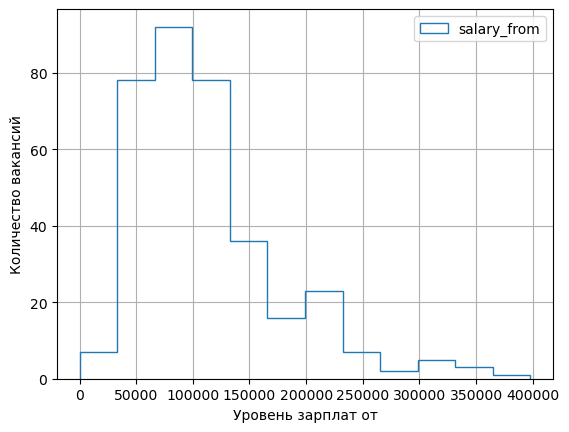

In [156]:
vacancies_da.plot(y='salary_from', kind='hist', bins=12,histtype='step', grid=True, xlabel='Уровень зарплат от',
                  ylabel='Количество вакансий');

Видим, что в основном предлагаемые заработные платы начинаются от 40000 рублей, при этом наибольшее количество работодателей предлагают зарплаты от 50000-120000 рублей.

In [159]:
# посмотрим, на каких вакансиях предлагают зарплату ниже 25000 рублей.
vacancies_da.query('salary_from <= 25000')

,id,name,published_at,alternate_url,type,employer,department,area,experience,key_skills,schedule,employment,description,description_lemmatized,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field,hard_skills_from_description,soft_skills_from_description,employer_low,key_skills_list,hard_skills_list,soft_skills_list,month
98,100568739,Аналитик данных,2024-06-06 10:46:09,https://hh.ru/vacancy/100568739,Открытая,НКМЗ-ГРУПП,,Нефтекамск,Junior (no experince),"['Работа в условиях многозадачности', 'Работа ...",Полный день,Полная занятость,обязанности: создание спецификаций по заявкам...,обязанность создание спецификация заявка произ...,25000.0,30000.0,Меньше 100 тысяч,"Пользователь ПК, Работа в команде, Умение рабо...",,,нкмз-групп,"[Пользователь ПК, Работа в команде, Умение раб...",[],[Работа в команде],6
1110,96943446,Аналитик данных в отдел развития на маркетплейсах,2024-05-11 21:45:07,https://hh.ru/vacancy/96943446,Открытая,Репетуев Иван Дмитриевич,,Москва,Junior (no experince),"['Аналитическое мышление', 'Аналитика продаж',...",Удаленная работа,Полная занятость,ищу в команду аналитика до глубины мозга косте...,искать команда аналитик глубина мозг кость име...,50.0,100001.0,От 100 тысяч до 200 тысяч,"Аналитика продаж, Конкурентная аналитика, Анал...",,,репетуев иван дмитриевич,"[Аналитика продаж, Конкурентная аналитика, Ана...",[Аналитика продаж],"[Аналитический склад ума, Аналитическое мышление]",5


В этих вакансиях нет специфических требований к претендентам как к аналитикам данных. Во второй вакансии, возможно, была опечатка в нижней границе заработной платы.

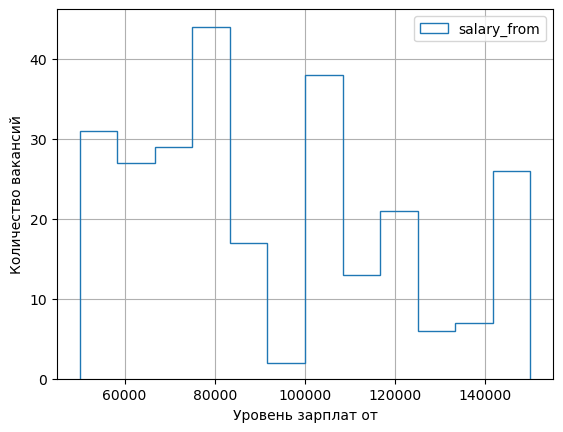

In [168]:
vacancies_da.plot(y='salary_from', kind='hist', bins=12, histtype='step', range=(50000, 150000), grid=True, xlabel='Уровень зарплат от',
                  ylabel='Количество вакансий');

Посмотрим, как распределяется заработная плата по грейдам

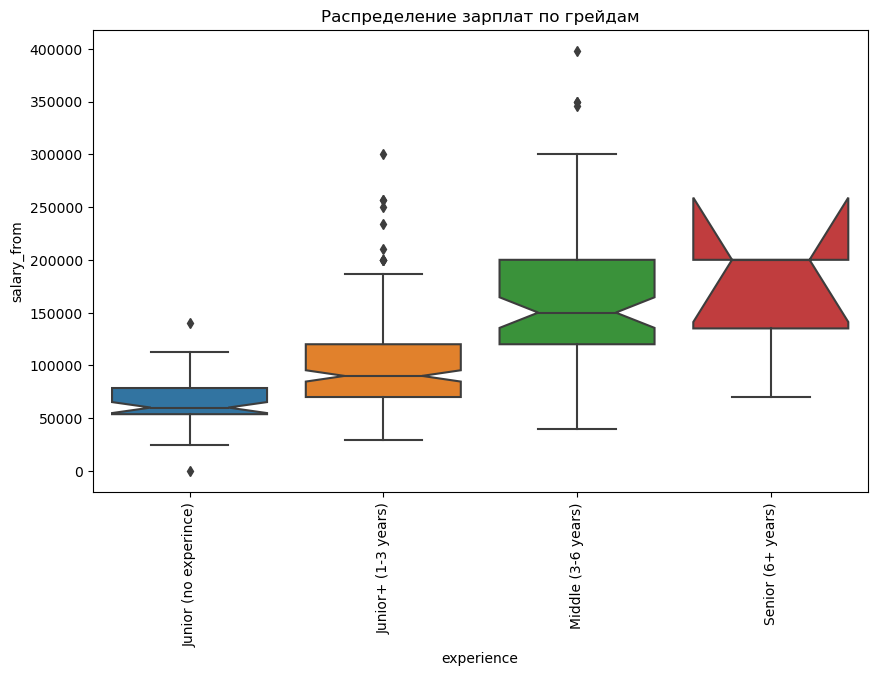

In [174]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=vacancies_da.experience, y=vacancies_da.salary_from, notch=True)
plt.xticks(rotation=90)
plt.title('Распределение зарплат по грейдам');

Заработную плату от 100000 рублей в основном предлагают претендентам уровня Junior+.

Теперь посмотрим на специалистов data science.

In [180]:
vacancies_ds['salary_from'].describe()

count        88.000000
mean     162650.772727
std       79280.231299
min       25000.000000
25%      100000.000000
50%      150000.000000
75%      200000.000000
max      350000.000000
Name: salary_from, dtype: float64

Здесь мы видим, что стартовая заработная плата начинается от 25000 рублей. Максимально стартовую зарплату предлагают в размере 350 000 рублей, но всего таких записей 88 штук. Средняя зарплата 150000 рублей,что гораздо выше, чем у аналитиков данных.

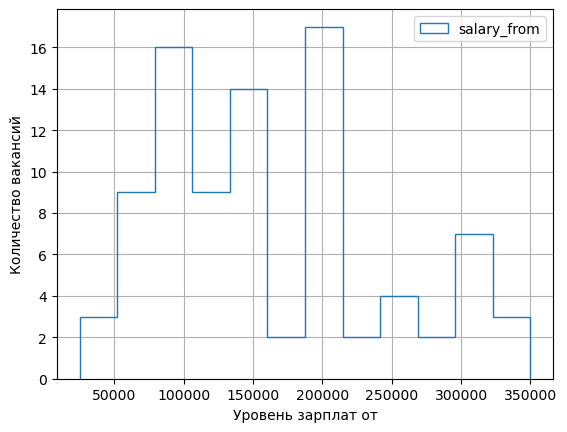

In [187]:
vacancies_ds.plot(y='salary_from', kind='hist', bins=12, histtype='step', grid=True, xlabel='Уровень зарплат от',
                  ylabel='Количество вакансий');

мы видим, что больше всего специалистам data science предлагают зарплату от 60000-200000 рублей.

Посмотрим на распределение по грейдам

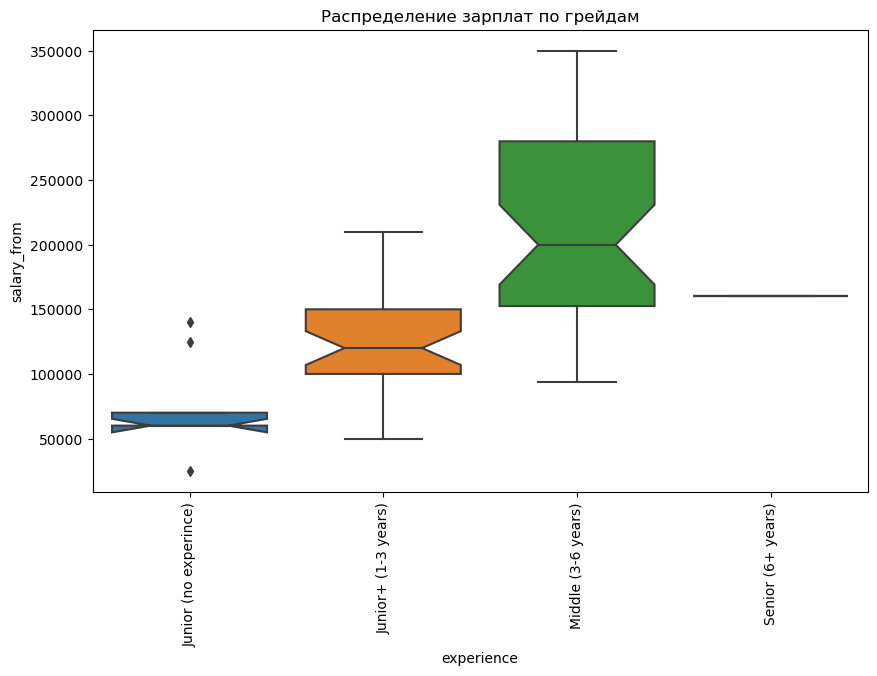

In [190]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=vacancies_ds.experience, y=vacancies_ds.salary_from, notch=True)
plt.xticks(rotation=90)
plt.title('Распределение зарплат по грейдам');

Как видим, уровень зарплат у data scientist выше.

Посмотрим на верхние границы зарплат.

In [193]:
vacancies_da['salary_to'].describe()

count       228.000000
mean     153846.714912
std       97255.738565
min       25000.000000
25%       85000.000000
50%      120000.000000
75%      200000.000000
max      497500.000000
Name: salary_to, dtype: float64

Аналитикам данных в среднем предлагают 120000 рублей как максимальную заработную плату.

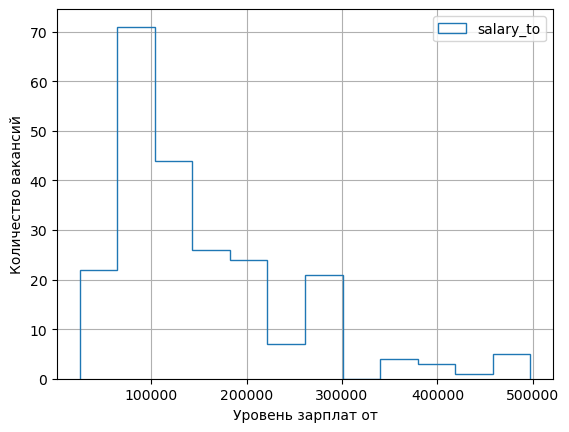

In [198]:
vacancies_da.plot(y='salary_to', kind='hist', bins=12, histtype='step', grid=True, xlabel='Уровень зарплат от',
                  ylabel='Количество вакансий');

Посмотрим, каким специалистам предлагают зарплату до 50000 рублей.

In [201]:
vacancies_da.query('salary_to <= 50000')

,id,name,published_at,alternate_url,type,employer,department,area,experience,key_skills,schedule,employment,description,description_lemmatized,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field,hard_skills_from_description,soft_skills_from_description,employer_low,key_skills_list,hard_skills_list,soft_skills_list,month
98,100568739,Аналитик данных,2024-06-06 10:46:09,https://hh.ru/vacancy/100568739,Открытая,НКМЗ-ГРУПП,,Нефтекамск,Junior (no experince),"['Работа в условиях многозадачности', 'Работа ...",Полный день,Полная занятость,обязанности: создание спецификаций по заявкам...,обязанность создание спецификация заявка произ...,25000.0,30000.0,Меньше 100 тысяч,"Пользователь ПК, Работа в команде, Умение рабо...",,,нкмз-групп,"[Пользователь ПК, Работа в команде, Умение раб...",[],[Работа в команде],6
105,100582516,Младший аналитик данных,2024-05-29 10:32:11,https://hh.ru/vacancy/100582516,Открытая,Topface Media,,Санкт-Петербург,Junior (no experince),"['Анализ данных', 'SQL', 'Python', 'Сбор и ана...",Полный день,Полная занятость,topface media — агентство по управлению репута...,topface media агентство управление репутация и...,30000.0,40000.0,Меньше 100 тысяч,"Python, SQL, Работа с базами данных, Анализ да...",Pandas,,topface media,"[Python, SQL, Работа с базами данных, Анализ д...","[Pandas, Python, SQL, Работа с базами данных, ...",[Сбор и анализ информации],5
293,101516298,Стажер Дата Аналитик,2024-06-10 16:06:06,https://hh.ru/vacancy/101516298,Открытая,Автомакон,,Москва,Junior (no experince),"['Проактивность', 'Документация', 'Pandas', 'К...",Удаленная работа,Стажировка,"наша программа стажировки — конкурс, в течение...",наш программа стажировка конкурс течение протя...,NaN,25000.0,Меньше 100 тысяч,"Проактивность, Документация, Pandas, Креативность",Pandas,"Документация, Проактивность, Креативность",автомакон,"[Проактивность, Документация, Pandas, Креативн...",[Pandas],"[Документация, Проактивность, Креативность]",6
337,101735125,Аналитик данных IVR,2024-06-11 12:59:07,https://hh.ru/vacancy/101735125,Открытая,СБЕР,Сбер для экспертов,Горно-Алтайск,Junior+ (1-3 years),[],Полный день,Полная занятость,ищем аналитика данных в канал виртуальный асси...,искать аналитика данные канал виртуальный асси...,45000.0,50000.0,Меньше 100 тысяч,,,,сбер,[],[],[],6
550,94076122,Специалист-аналитик данных,2024-03-14 10:17:18,https://hh.ru/vacancy/94076122,Открытая,Ростелеком,,Нижний Новгород,Junior+ (1-3 years),"['сводные таблицы', 'BI-отчетность', 'Аналитик...",Полный день,Полная занятость,чем предстоит заниматься: работа с реестрам...,предстоять заниматься работа реестр база данны...,28940.0,36175.0,Меньше 100 тысяч,"MS Excel, BI-отчетность, ВПР, сводные таблицы,...",,Переговоры,ростелеком,"[MS Excel, BI-отчетность, ВПР, сводные таблицы...","[MS Excel, ВПР, Аналитика]","[Переговоры, Аналитическое мышление, Подготовк...",3
598,94387369,Аналитик данных,2024-03-07 10:28:22,https://hh.ru/vacancy/94387369,Открытая,Группа Компаний «Линия7»,,Пермь,Junior+ (1-3 years),"['Анализ данных', 'Хранилище данных', '1С: Тор...",Полный день,Полная занятость,гк &quot;линия 7&quot; приглашает в свою коман...,гк quot линия 7 quot приглашать свой команда q...,40700.0,40700.0,Меньше 100 тысяч,"Хранилище данных, MS Excel, Табличная верстка,...",,Аналитическое мышление,группа компаний «линия7,"[Хранилище данных, MS Excel, Табличная верстка...","[MS Excel, Работа с базами данных, Анализ данных]",[Аналитическое мышление],3
979,96176248,Аналитик данных IVR,2024-04-04 12:43:00,https://hh.ru/vacancy/96176248,Открытая,СБЕР,Сбер для экспертов,Адыгейск,Junior+ (1-3 years),[],Полный день,Полная занятость,ищем аналитика данных в канал виртуальный асси...,искать аналитика данные канал виртуальный асси...,45000.0,50000.0,Меньше 100 тысяч,,,,сбер,[],[],[],4
1029,96486859,Оператор 1С (аналитик данных),2024-04-24 08:16:25,https://hh.ru/vacancy/96486859,Открытая,АктивПромКапитал,,Екатеринбург,Junior (no experince),"['Деловая переписка', 'МС Excel', 'Google Shee...",По

В основном это Junior (no experince) и Junior+ (1-3 years) специалисты на стажировке.

Видим, что больше всего предлагают максимальную зарплату в 100000-120000 рублей.

In [219]:
vacancies_ds['salary_to'].describe()

count        82.000000
mean     262430.097561
std      121160.488980
min       25000.000000
25%      192500.000000
50%      292500.000000
75%      350000.000000
max      550000.000000
Name: salary_to, dtype: float64

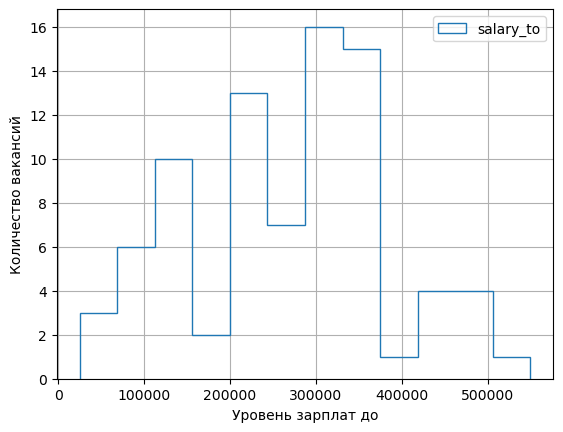

In [230]:
vacancies_ds.plot(y='salary_to', kind='hist', bins=12, histtype='step', grid=True,
                  xlabel='Уровень зарплат до', ylabel='Количество вакансий');

In [223]:
vacancies_ds[vacancies_ds['salary_to']<= 50000]

,id,name,published_at,alternate_url,type,employer,department,area,experience,key_skills,schedule,employment,description,description_lemmatized,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field,hard_skills_from_description,soft_skills_from_description,employer_low,key_skills_list,hard_skills_list,soft_skills_list,month
128,101516287,Стажер Data scientist/MLE,2024-06-10 16:05:56,https://hh.ru/vacancy/101516287,Открытая,Автомакон,,Москва,Junior (no experince),"['Pandas', 'Проактивность', 'Креативность']",Удаленная работа,Стажировка,в течение 14 лет мы искали и находили опытных ...,течение 14 год искать находить опытный специал...,NaN,25000.0,Меньше 100 тысяч,"Pandas, Проактивность, Креативность",Pandas,"Проактивность, Креативность",автомакон,"[Pandas, Проактивность, Креативность]",[Pandas],"[Проактивность, Креативность]",6
473,95322520,Data Science Project,2024-03-23 00:06:09,https://hh.ru/vacancy/95322520,Открытая,К2-Техно,,Москва,Junior+ (1-3 years),"['Python', 'Pandas', 'Английский язык', 'Data ...",Полный день,Проектная работа,описание вакансии:анализ жизненно важных показ...,описание вакансия анализ жизненно важный показ...,NaN,30000.0,Меньше 100 тысяч,"Python, Data Analysis, Английский язык, Pandas",Pandas,,к2-техно,"[Python, Data Analysis, Английский язык, Pandas]","[Pandas, Python, Data Analysis, Английский язык]",[],3
474,95322521,Data Science Project,2024-03-23 00:06:09,https://hh.ru/vacancy/95322521,Открытая,К2-Техно,,Санкт-Петербург,Junior+ (1-3 years),"['Python', 'Pandas', 'Английский язык', 'Data ...",Полный день,Проектная работа,описание вакансии:анализ жизненно важных показ...,описание вакансия анализ жизненно важный показ...,NaN,30000.0,Меньше 100 тысяч,"Python, Data Analysis, Английский язык, Pandas",Pandas,,к2-техно,"[Python, Data Analysis, Английский язык, Pandas]","[Pandas, Python, Data Analysis, Английский язык]",[],3


специалистам data science предлагают зарплату ниже 50000 рублей только на стажировке или проектной работе специалистам уровня Junior и Junior+.

Специалистам data science верхняя планка зарплат в среднем установлена на уровне в 300000 рублей.

Посмотрим есть ли зависимость между нижней и верхней планкой заработной платы.

Коэффициент корреляции: 0.93


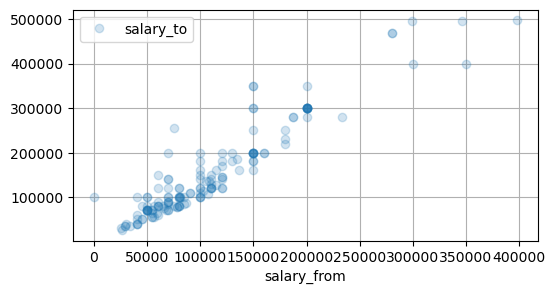

In [228]:
vacancies_da.plot(x='salary_from', y='salary_to', style='o', grid=True, alpha=0.2, figsize=(6,3))
print('Коэффициент корреляции:',round(vacancies_da['salary_from'].corr(vacancies_da['salary_to']), 2))

Коэффициент корреляции: 0.85


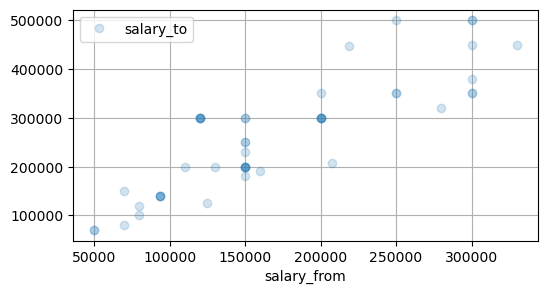

In [232]:
vacancies_ds.plot(x='salary_from', y='salary_to', style='o', grid=True, alpha=0.2, figsize=(6,3))
print('Коэффициент корреляции:',round(vacancies_ds['salary_from'].corr(vacancies_ds['salary_to']), 2))

Как мы видим есть прямая зависимость нижней и верхней планки зарплат как у аналитиков, так и у специалистов data science.  При этом уровень зарплат последних выше, чем у аналитиков.

### Определение доли грейдов среди вакансий

Посмотрим сколько вакансий опубликовано для каждого грейда аналитиков и специалистов data science.

In [237]:
# посчитаем сколько вакансий по каждому грейду опубликовано для аналитиков
experience = vacancies_da.pivot_table(index = 'experience', values='id', aggfunc=['count'])
experience.columns = ['vacancies_da_count']
experience['da_percent'] = round(experience['vacancies_da_count']/vacancies_da.shape[0]*100,2)
experience

,vacancies_da_count,da_percent
experience,,
Junior (no experince),142,7.88
Junior+ (1-3 years),1091,60.58
Middle (3-6 years),555,30.82
Senior (6+ years),13,0.72


Видим, что больше всего вакансий для аналитиков уровня Junior+ (1-3 years), на втором месте Middle (3-6 years).

Теперь посмотрим на специалистов data science.

In [240]:
experience_science = vacancies_ds.pivot_table(index = 'experience', values='id', aggfunc=['count'])
experience_science.columns = ['vacancies_ds_count']
experience['vacancies_ds_count'] = experience_science['vacancies_ds_count']
experience['ds_percent'] = round(experience['vacancies_ds_count']/vacancies_ds.shape[0]*100,2)
experience

,vacancies_da_count,da_percent,vacancies_ds_count,ds_percent
experience,,,,
Junior (no experince),142,7.88,44,4.52
Junior+ (1-3 years),1091,60.58,433,44.46
Middle (3-6 years),555,30.82,465,47.74
Senior (6+ years),13,0.72,32,3.29


у специалистов data science практически одинаково требуются сотрудники уровня Middle (3-6 years) и Junior+ (1-3 years).

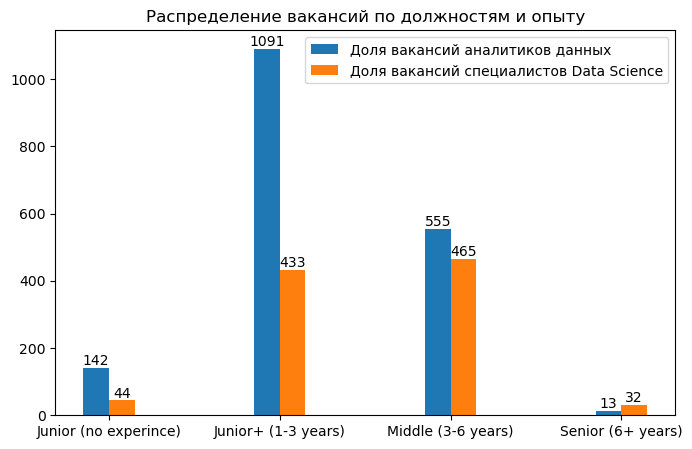

In [249]:
width = 0.15
x = np.arange(experience.shape[0])

fig, ax = plt.subplots(figsize=(8,5))
#data_type = data_type.sort_values(by='total_count')
rects1 = ax.bar(x - width/2, experience['vacancies_da_count'], width, label='Доля вакансий аналитиков данных')
rects2 = ax.bar(x + width/2, experience['vacancies_ds_count'], width, label='Доля вакансий специалистов Data Science')
ax.bar_label(rects1)
ax.bar_label(rects2)
ax.set_title('Распределение вакансий по должностям и опыту')
ax.set_xticks(x)
ax.set_xticklabels(experience.index)
ax.legend()
plt.show()


Как видим ситуация у аналитиков и специалистов data science различаются: на должность аналитика данных чаще всего требуются люди с опытом работы 1-3 года, а на должность специалиста data science больше всего требуются люди с более богатым опытом работы 3-6 лет, специалистов без опыта работы чаще ищут на должность аналитика, в то время как людей с опытом более 6 лет  - на должность специалиста data science.

### Топ-5 работодателей по грейдам

Теперь найдем топ-5 работодателей по количеству вакансий для каждого грейда для аналитиков и специалистов data science.


Грейд:Junior (no experince)


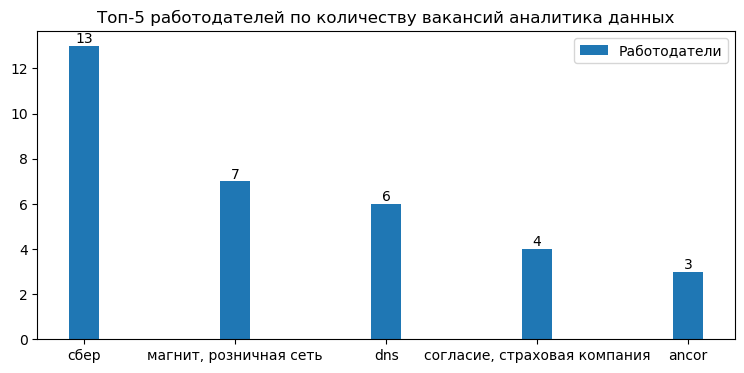


Грейд:Junior+ (1-3 years)


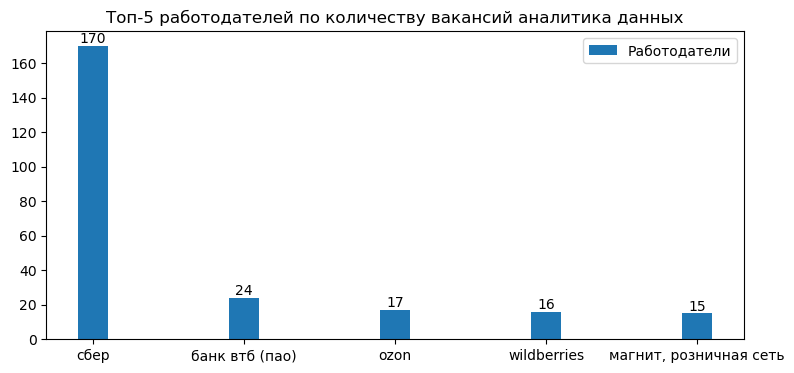


Грейд:Middle (3-6 years)


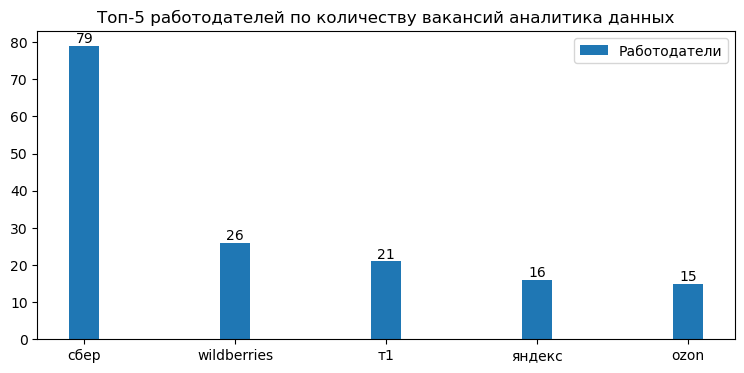


Грейд:Senior (6+ years)


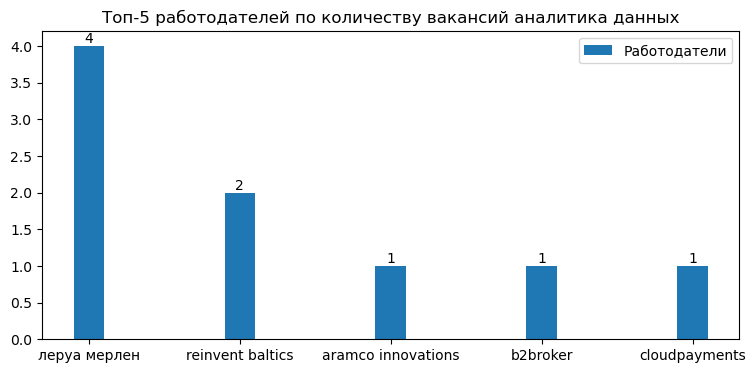


Грейд:Junior (no experince)


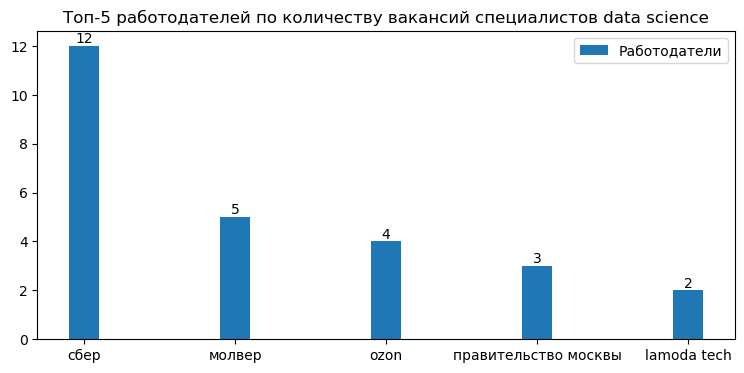


Грейд:Junior+ (1-3 years)


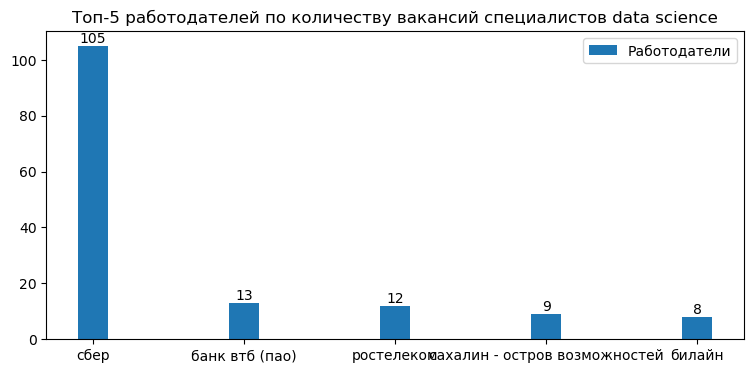


Грейд:Middle (3-6 years)


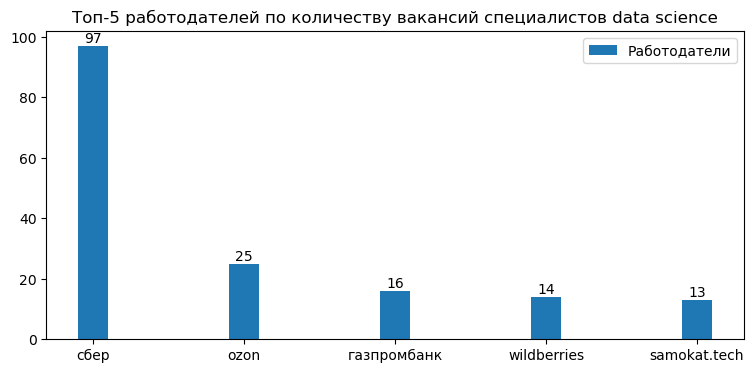


Грейд:Senior (6+ years)


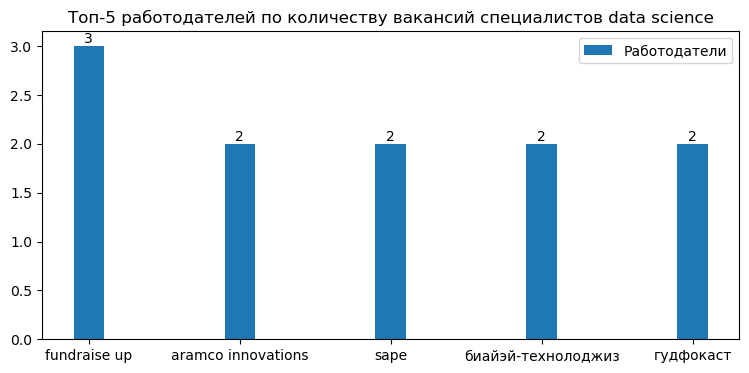

In [253]:
# создадим функцию, которая определяет топ-5 работодателей по количеству вакансий для каждого грейда
def top_employers_by_grade(df, grade, n=5):
    top_df = df[df['experience'] == grade].nlargest(n, 'v_count') #для каждого грейда определяем топ-5 количеств вакансий
    top_df['experience'] = grade  # добавляем столбец 'experience'
    return top_df[['experience', 'employer_low', 'v_count']]

# для каждого грейда и работодателя считаем количество опубликованных вакансий
count_by_grade_employer_da = vacancies_da.groupby(['experience', 'employer_low']).size().reset_index(name='v_count')
count_by_grade_employer_ds = vacancies_ds.groupby(['experience', 'employer_low']).size().reset_index(name='v_count')
#print(count_by_grade_employer.head())
# создадим список грейдов
grades = vacancies_da['experience'].unique()
# собираем один датафрейм со всеми грейдами и топ-5 работодателями
top_employers_da = pd.concat([top_employers_by_grade(count_by_grade_employer_da, grade) for grade in grades])
top_employers_ds = pd.concat([top_employers_by_grade(count_by_grade_employer_ds, grade) for grade in grades])


# построим отдельные диаграммы для каждого грейда аналитиков
for grade in grades:
    data = top_employers_da[top_employers_da['experience']==grade]
    print('')
    print ('Грейд:' + grade)
    width = 0.2
    x = np.arange(data.shape[0])

    fig, ax = plt.subplots(figsize=(9,4))

    rects1 = ax.bar(x, data['v_count'], width, label='Работодатели')
    ax.bar_label(rects1)
    ax.set_title('Топ-5 работодателей по количеству вакансий аналитика данных')
    ax.set_xticks(x)
    ax.set_xticklabels(data['employer_low'])
    ax.legend()
    plt.show()

# построим отдельные диаграммы для каждого грейда специалистов data science
for grade in grades:
    data = top_employers_ds[top_employers_ds['experience']==grade]
    print('')
    print ('Грейд:' + grade)
    width = 0.2
    x = np.arange(data.shape[0])

    fig, ax = plt.subplots(figsize=(9,4))

    rects1 = ax.bar(x, data['v_count'], width, label='Работодатели')
    ax.bar_label(rects1)
    ax.set_title('Топ-5 работодателей по количеству вакансий специалистов data science')
    ax.set_xticks(x)
    ax.set_xticklabels(data['employer_low'])
    ax.legend()
    plt.show()

Сбер и его подразделения - самый крупный работодатель, как для аналитиков, так и для специалистов data science, для специалистов уровня Junior, Junior+ и Middle. Также таких специалистов ищут маркетплейсы, банки, сети магазинов. Специалистов уровня Senior ищут гораздо меньше компаний, возможно, это всязано с внутренним рекрутингом и вертикальным ростом.  

### Уровень заработной платы

Посчитаем среднюю заработную плату, которую предлагают работодатели по грейдам

In [258]:
salary_from_da = vacancies_da.pivot_table(index='experience',values='salary_from',aggfunc='mean')
salary_from_da.columns=['mean_salary']
salary_from_da.reset_index(inplace=True)
salary_from_da

,experience,mean_salary
0,Junior (no experince),64701.696429
1,Junior+ (1-3 years),98010.467290
2,Middle (3-6 years),173962.600000
3,Senior (6+ years),156666.666667


In [260]:
salary_to_da = vacancies_da.pivot_table(index='experience',values='salary_to',aggfunc='mean')
salary_to_da.columns = ['mean_salary']
salary_to_da.reset_index(inplace=True)
salary_to_da

,experience,mean_salary
0,Junior (no experince),73330.764706
1,Junior+ (1-3 years),129879.465649
2,Middle (3-6 years),247370.409836
3,Senior (6+ years),240000.000000


In [262]:
salary = pd.DataFrame(columns=['experience','mean_salary'])
salary['experience'] = salary_from_da['experience']
salary['mean_salary'] = round((salary_from_da['mean_salary'] + salary_to_da['mean_salary']) / 2, 2)
#salary.reset_index(inplace=True)
salary

,experience,mean_salary
0,Junior (no experince),69016.23
1,Junior+ (1-3 years),113944.97
2,Middle (3-6 years),210666.50
3,Senior (6+ years),198333.33


In [264]:
salary_new = salary_from_da.merge(salary_to_da, on='experience',how='left')
salary_new.columns = ['experience','salary_from', 'salary_to']
salary_new
salary = salary_new.merge(salary, on='experience', how='left')
salary['mean_RF_2023'] = 74854
salary

,experience,salary_from,salary_to,mean_salary,mean_RF_2023
0,Junior (no experince),64701.696429,73330.764706,69016.23,74854
1,Junior+ (1-3 years),98010.467290,129879.465649,113944.97,74854
2,Middle (3-6 years),173962.600000,247370.409836,210666.50,74854
3,Senior (6+ years),156666.666667,240000.000000,198333.33,74854


Таким образом мы видим, что в среднем аналитикам данных предлагают от 70 000 до 210 000 рублей в зависимости от грейда, при этом специалистам уровня Senior в среднем предлагают зарплату меньше, чем специалистам уровня Middle.

Согласно официальным данным Росстата в 2023 году средняя заработная плата по России составила  74854 рубля (https://rosstat.gov.ru/labor_market_employment_salaries), ссылка на файл с данными: https://docs.google.com/spreadsheets/d/1ABsrUm3Ez1uqcNhRxaCvScgb2tIsjRyF/edit?usp=sharing&ouid=107826230984105387228&rtpof=true&sd=true

Таким образом, аналитикам уровня Junior (no experince)	в среднем предлагают зарплату ниже средней по РФ.

Посмотрим зарплаты специалистов data science.

In [268]:
salary_from_ds = vacancies_ds.pivot_table(index='experience',values='salary_from',aggfunc='mean')
salary_from_ds.columns=['mean_salary']
salary_from_ds.reset_index(inplace=True)
salary_to_ds = vacancies_ds.pivot_table(index='experience',values='salary_to',aggfunc='mean')
salary_to_ds.columns = ['mean_salary']
salary_to_ds.reset_index(inplace=True)
salary_ds = pd.DataFrame(columns=['experience','mean_salary'])
salary_ds['experience'] = salary_from_ds['experience']
salary_ds['mean_salary'] = round((salary_from_ds['mean_salary'] + salary_to_ds['mean_salary']) / 2, 2)
salary_new_ds = salary_from_ds.merge(salary_to_ds, on='experience',how='left')
salary_new_ds.columns = ['experience','salary_from', 'salary_to']
salary_ds = salary_new_ds.merge(salary_ds, on='experience', how='left')
salary_ds['mean_RF_2023'] = 74854
salary_ds

,experience,salary_from,salary_to,mean_salary,mean_RF_2023
0,Junior (no experince),73333.555556,77438.000000,75385.78,74854
1,Junior+ (1-3 years),124250.000000,231282.051282,177766.03,74854
2,Middle (3-6 years),214768.238095,309708.777778,262238.51,74854
3,Senior (6+ years),160000.000000,346666.666667,253333.33,74854


Таким образом мы видим, что в среднем специалистам data science предлагают от 75 000 до 260 000 рублей в зависимости от грейда, при этом так же как и аналитикам специалистам уровня Senior в среднем предлагают зарплату меньше, чем специалистам уровня Middle.
Специалистам data science уровня Junior (no experince)	в среднем предлагают зарплату чуть выше средней по РФ.

### Тип занятости

In [277]:
vacancies_da.pivot_table(index='experience', columns='employment', values='name', aggfunc='count')

employment,Полная занятость,Проектная работа,Стажировка,Частичная занятость
experience,,,,
Junior (no experince),123.0,1.0,15.0,3.0
Junior+ (1-3 years),1079.0,3.0,1.0,8.0
Middle (3-6 years),549.0,1.0,NaN,5.0
Senior (6+ years),13.0,NaN,NaN,NaN


В основном работодатели готовы предложить аналитикам данных трудовой контракт, начинающим специалистам так же могут предложить стажировку.

In [280]:
vacancies_ds.pivot_table(index='experience', columns='employment', values='name', aggfunc='count')

employment,Полная занятость,Проектная работа,Стажировка,Частичная занятость
experience,,,,
Junior (no experince),26.0,1.0,17.0,NaN
Junior+ (1-3 years),422.0,2.0,2.0,7.0
Middle (3-6 years),462.0,2.0,NaN,1.0
Senior (6+ years),32.0,NaN,NaN,NaN


### График работы

In [283]:
vacancies_da.pivot_table(index='experience', columns='schedule', values='name', aggfunc='count')

schedule,Гибкий график,Полный день,Сменный график,Удаленная работа
experience,,,,
Junior (no experince),3.0,122.0,2.0,15.0
Junior+ (1-3 years),21.0,905.0,7.0,158.0
Middle (3-6 years),17.0,406.0,NaN,132.0
Senior (6+ years),NaN,8.0,NaN,5.0


In [285]:
vacancies_ds.pivot_table(index='experience', columns='schedule', values='name', aggfunc='count')

schedule,Гибкий график,Полный день,Сменный график,Удаленная работа
experience,,,,
Junior (no experince),7.0,28.0,NaN,9.0
Junior+ (1-3 years),15.0,316.0,3.0,99.0
Middle (3-6 years),19.0,355.0,1.0,90.0
Senior (6+ years),2.0,24.0,1.0,5.0


Работодатели предпочитают, чтобы сотрудники работали в офисе полный день, удаленную работу в основном предлагают специалистам уровня Junior+ и Middle, так же как и гибкий график, специалисты уровня Senior могут выбирать между работой в офисе и удаленной работой.

Таким образом можно сделать вывод о типичном месте работы для аналитика и специалиста data science:

- Junior аналитик работает в Сбере (и его подразделениях) или сети магазинов в офисе полный рабочий день с зарплатой от 64000 до 73000 рублей;
- аналитик Junior+ также работает в Сбере в офисе полный рабочий день с зарплатой от 98000 до 130000 рублей;
- Middle аналитик в качестве места работы может выбрать Сбер или маркетплейс или банк, работает полный день из офиса (75% случаев ) или удаленно (25% ) и получает от 175000 до 245000 рублей;
- аналитик Senior получает за свой труд от 155000 до 240000 рублей, работая полный рабочий день, чаще из офиса, чем удаленно, но не сильно больше, работает в крупных компаниях, сетях магазинов.

специалисты data science:

- Junior специалист получает от 73000 до 77000 рублей, работая в Сбере полный день;
- Junior+ работает в СБере, получает от 124000 до 230000 рублей;
- Middle специалист в Сбере или маркетплейсе получает от 214000 до 309000 рублей;
- Senior работает в крупных международных компаниях, получает от 160000 до 345000 рублей.

### Hard или Soft ? Какие навыки спрашивают чаще

In [337]:
# Функция для подсчета количества элементов в массиве навыков
def count_hard_skills(row):
    return len(row['hard_skills_list'])
def count_soft_skills(row):
    return len(row['soft_skills_list'])

# Создаем новый столбец с количеством скилов
vacancies_da['skill_count_hard'] = vacancies_da.apply(count_hard_skills, axis=1)
vacancies_da['skill_count_soft'] = vacancies_da.apply(count_soft_skills, axis=1)
vacancies_ds['skill_count_hard'] = vacancies_ds.apply(count_hard_skills, axis=1)
vacancies_ds['skill_count_soft'] = vacancies_ds.apply(count_soft_skills, axis=1)
# Группируем по грейду и суммируем количество скилов
result_da = vacancies_da.groupby('experience')[['skill_count_hard','skill_count_soft']].sum()
result_ds = vacancies_ds.groupby('experience')[['skill_count_hard','skill_count_soft']].sum()
result_da['hard_skill'] = round(result_da['skill_count_hard'] / experience['vacancies_da_count'],2)
result_da['soft_skill'] = round(result_da['skill_count_soft'] / experience['vacancies_da_count'],2)
result_ds['hard_skill'] = round(result_ds['skill_count_hard'] / experience['vacancies_ds_count'],2)
result_ds['soft_skill'] = round(result_ds['skill_count_soft'] / experience['vacancies_ds_count'],2)
print('АНАЛИТИКИ ДАННЫХ')
print(result_da)
print()
print('DATA SCIENCE')
print(result_ds)

АНАЛИТИКИ ДАННЫХ
                       skill_count_hard  skill_count_soft  hard_skill  \
experience                                                              
Junior (no experince)               288               137        2.03   
Junior+ (1-3 years)                3127               910        2.87   
Middle (3-6 years)                 1821               421        3.28   
Senior (6+ years)                    70                21        5.38   

                       soft_skill  
experience                         
Junior (no experince)        0.96  
Junior+ (1-3 years)          0.83  
Middle (3-6 years)           0.76  
Senior (6+ years)            1.62  

DATA SCIENCE
                       skill_count_hard  skill_count_soft  hard_skill  \
experience                                                              
Junior (no experince)               100                12        2.27   
Junior+ (1-3 years)                1320               167        3.05   
Middle (3-6 years)    

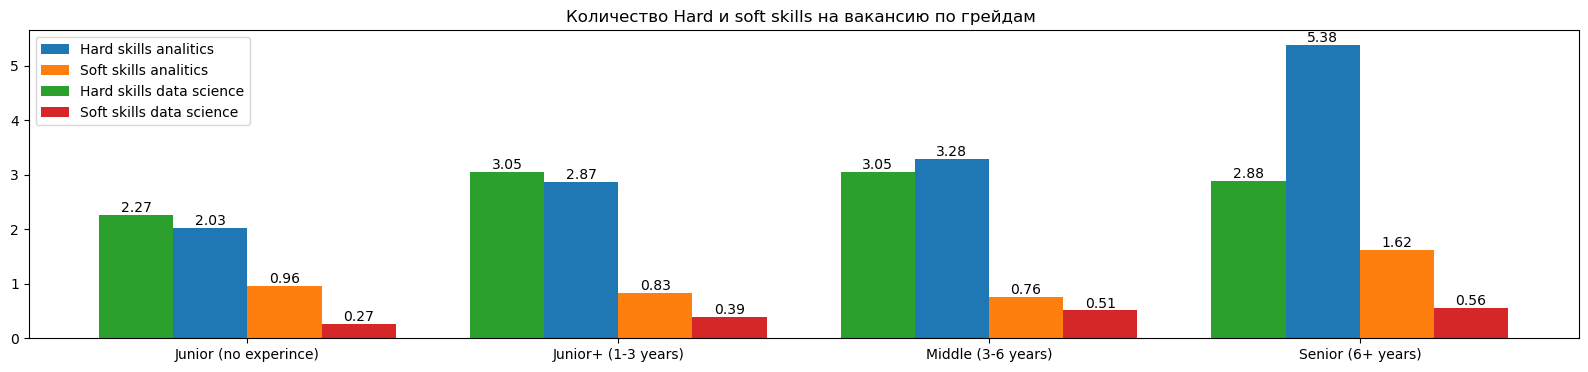

In [341]:
width = 0.2
x = np.arange(result_da.shape[0])

fig, ax = plt.subplots(figsize=(20,4))
rects1 = ax.bar(x-width/2, result_da['hard_skill'], width, label='Hard skills analitics')
rects2 = ax.bar(x + width/2, result_da['soft_skill'], width, label='Soft skills analitics')
rects3 = ax.bar(x-3*width/2, result_ds['hard_skill'], width, label='Hard skills data science')
rects4 = ax.bar(x +3*width/2, result_ds['soft_skill'], width, label='Soft skills data science')
ax.bar_label(rects1)
ax.bar_label(rects2)
ax.bar_label(rects3)
ax.bar_label(rects4)
ax.set_title('Количество Hard и soft skills на вакансию по грейдам ')
ax.set_xticks(x)
ax.set_xticklabels(result_da.index)
ax.legend(loc='best')
plt.show()

Аналитикам данных и специалистам data science больше всего важно обладание hard скиллами, причем специалистам data science они важнее, а вот soft скиллы больше нужны аналитикам данных и senior специалистам data science.

### Какие hard и soft skills нужны для работы?

Посмотрим какие именно hard и soft skills нужны аналитикам и специалистам data science. составим топ-5 самых востребованных скиллов.

In [346]:
# создаем функцию, которая возвращает n наибольших значений строки
def get_skills(row,n=5):
    return row.nlargest(n)
# из всего датафрейма возьмем  только три столбца с грейдами, hard-скиллами и soft-скиллами
data_da = vacancies_da[['experience','hard_skills_list','soft_skills_list']]
# развернем списки скиллов в отдельные строки датафрейма
data_da_hard = data_da.explode('hard_skills_list')
data_da_soft = data_da.explode('soft_skills_list')
# создадим кросс-таблицы, в которых у каждого скилла для каждого грейда стоит количество раз его упоминания
data_da_hard = pd.crosstab(data_da_hard['experience'],data_da_hard['hard_skills_list'])
data_da_soft = pd.crosstab(data_da_soft['experience'],data_da_soft['soft_skills_list'])
# оставляем для каждого грейда топ-5 наиболее встречающихся скиллов
data_da_hard = data_da_hard.apply(get_skills, axis=1)
data_da_soft = data_da_soft.apply(get_skills, axis=1)

print(data_da_hard)
print(data_da_soft)

hard_skills_list       MS Excel  Pandas  Power BI  Python    SQL  confluence  \
experience                                                                     
Junior (no experince)      28.0    19.0       NaN    34.0   37.0         NaN   
Junior+ (1-3 years)       140.0   177.0       NaN   321.0  469.0         NaN   
Middle (3-6 years)          NaN   104.0      72.0   217.0  250.0         NaN   
Senior (6+ years)           NaN     4.0       4.0     9.0    9.0         4.0   

hard_skills_list       Анализ данных  
experience                            
Junior (no experince)           31.0  
Junior+ (1-3 years)            262.0  
Middle (3-6 years)             114.0  
Senior (6+ years)                NaN  
soft_skills_list       Анализ рынка  Аналитическое мышление  Документация  \
experience                                                                  
Junior (no experince)           NaN                    40.0          17.0   
Junior+ (1-3 years)             NaN                   

In [348]:
# Получим такие же таблицы для специалистов data science
# из всего датафрейма возьмем  только три столбца с грейдами, hard-скиллами и soft-скиллами
data_ds = vacancies_ds[['experience','hard_skills_list','soft_skills_list']]
# развернем списки скиллов в отдельные строки датафрейма
data_ds_hard = data_ds.explode('hard_skills_list')
data_ds_soft = data_ds.explode('soft_skills_list')
# создадим кросс-таблицы, в которых у каждого скилла для каждого грейда стоит количество раз его упоминания
data_ds_hard = pd.crosstab(data_ds_hard['experience'],data_ds_hard['hard_skills_list'])
data_ds_soft = pd.crosstab(data_ds_soft['experience'],data_ds_soft['soft_skills_list'])
# оставляем для каждого грейда топ-5 наиболее встречающихся скиллов
data_ds_hard = data_ds_hard.apply(get_skills, axis=1)
data_ds_soft = data_ds_soft.apply(get_skills, axis=1)

print(data_ds_hard)
print(data_ds_soft)

hard_skills_list       Data Mining  Data Science  Git    ML  Machine Learning  \
experience                                                                      
Junior (no experince)          7.0           NaN  6.0   NaN               NaN   
Junior+ (1-3 years)            NaN           NaN  NaN   NaN              67.0   
Middle (3-6 years)             NaN           NaN  NaN  66.0              55.0   
Senior (6+ years)              NaN           5.0  NaN   5.0               NaN   

hard_skills_list       Pandas  Python    SQL  Математическая статистика  
experience                                                               
Junior (no experince)     7.0    17.0    NaN                        9.0  
Junior+ (1-3 years)     195.0   195.0  138.0                       42.0  
Middle (3-6 years)      166.0   215.0  113.0                        NaN  
Senior (6+ years)         7.0    12.0    6.0                        NaN  
soft_skills_list        CV  Адаптивность  Аналитическое мышление  \
e

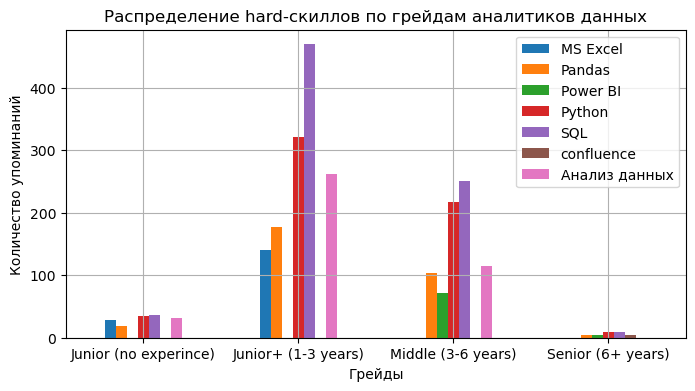

In [350]:
data_da_hard.plot(kind='bar',grid=True,figsize=(8,4));
plt.xlabel('Грейды')
plt.ylabel('Количество упоминаний');
plt.title('Распределение hard-скиллов по грейдам аналитиков данных');
plt.legend(loc='best');
plt.xticks(np.arange(len(data_da_hard)), data_da_hard.index,rotation=0);
plt.show();

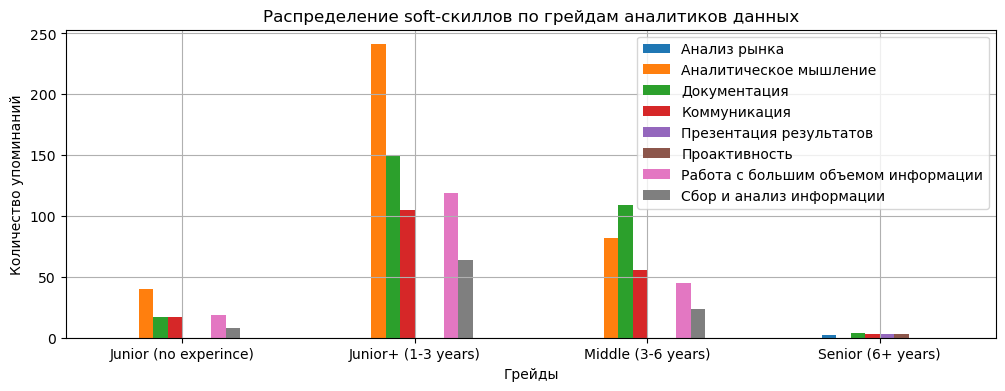

In [352]:
data_da_soft.plot(kind='bar',grid=True,figsize=(12,4));
plt.xlabel('Грейды')
plt.ylabel('Количество упоминаний');
plt.title('Распределение soft-скиллов по грейдам аналитиков данных');
plt.legend(loc='best');
plt.xticks(np.arange(len(data_da_soft)), data_da_soft.index,rotation=0);
plt.show();

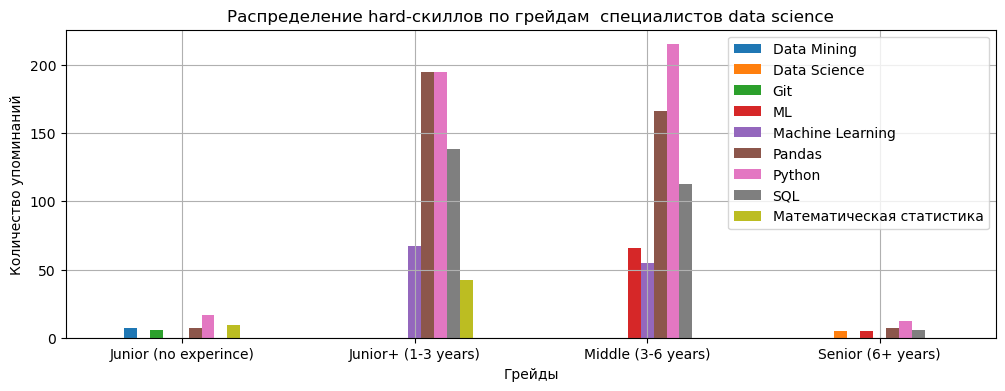

In [354]:
data_ds_hard.plot(kind='bar',grid=True,figsize=(12,4));
plt.xlabel('Грейды')
plt.ylabel('Количество упоминаний');
plt.title('Распределение hard-скиллов по грейдам  специалистов data science');
plt.legend(loc='best');
plt.xticks(np.arange(len(data_ds_hard)), data_ds_hard.index,rotation=0);
plt.show();

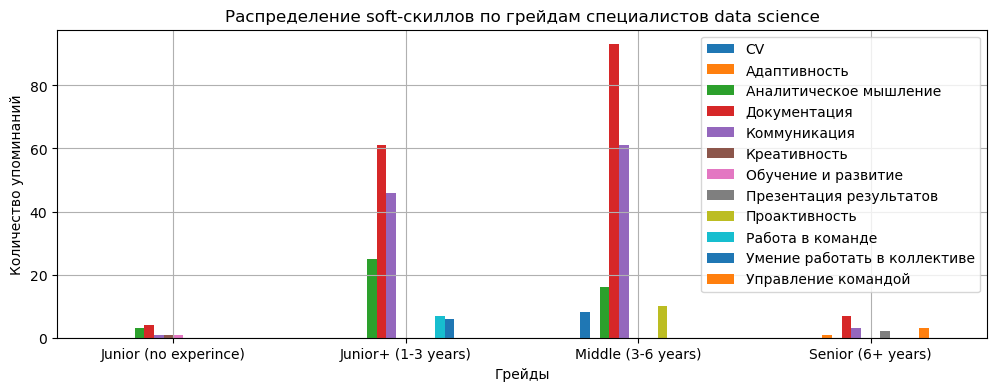

In [356]:
data_ds_soft.plot(kind='bar',grid=True,figsize=(12,4));
plt.xlabel('Грейды')
plt.ylabel('Количество упоминаний');
plt.title('Распределение soft-скиллов по грейдам специалистов data science');
plt.legend(loc='best');
plt.xticks(np.arange(len(data_ds_soft)), data_ds_soft.index,rotation=0);
plt.show();

Как видим аналитикам данных на любом уровне важно знать Python и Pandas в частности, SQL, специалистам грейда Junior также важно уметь работать с Excel, а вот для Middle и Senior -  в большей степени уметь анализировать данные. Из soft скиллов важно иметь аналитическое мышление, уметь работать с документацией и большими объемами информации и быть коммуникабельными.

У специалистов data science картина несколько другая: важны Python и Pandas в частности, SQL и Machine Learning, Junor специалисты должны знать математическую статистику. Из soft скиллов можно выделить как самые важные - работа с документацией и коммуникабельность, а также иметь аналитическое мышление.

### Динамика количества вакансий

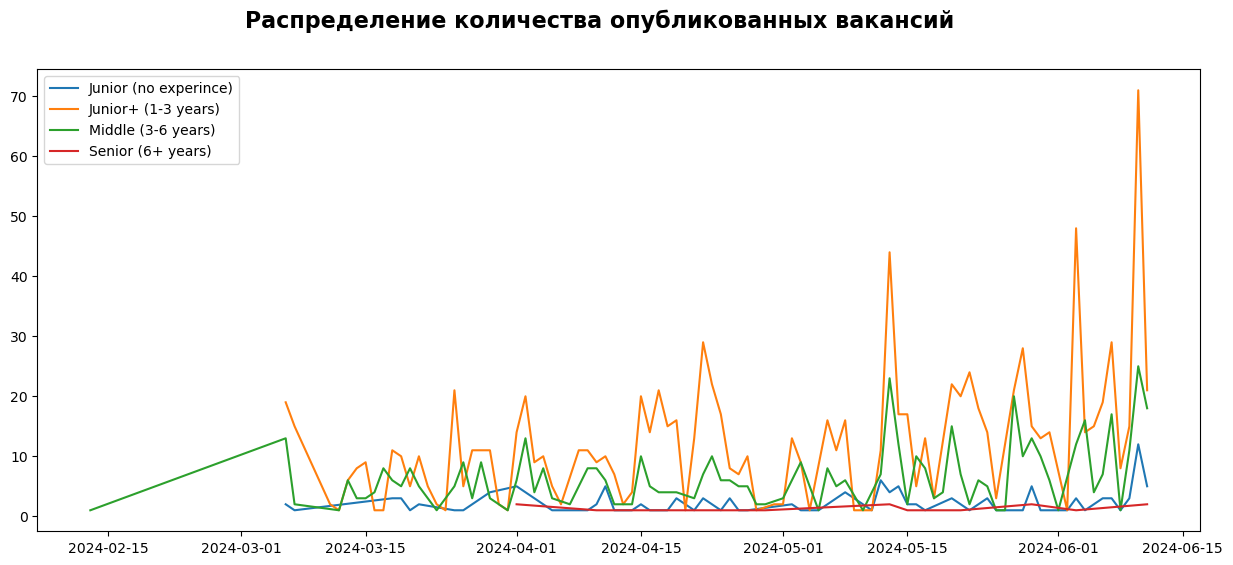

In [423]:
plt.figure(figsize=[15, 6])
plt. suptitle('Распределение количества опубликованных вакансий', fontsize=16, fontweight='bold')

for t in vacancies_da['experience'].unique():
    vacancies_da['date'] = pd.to_datetime(vacancies_da['published_at']).dt.date
    plt.plot(vacancies_da[vacancies_da['experience']==t].groupby('date')['id'].count(), label=t)
    plt.legend()
  


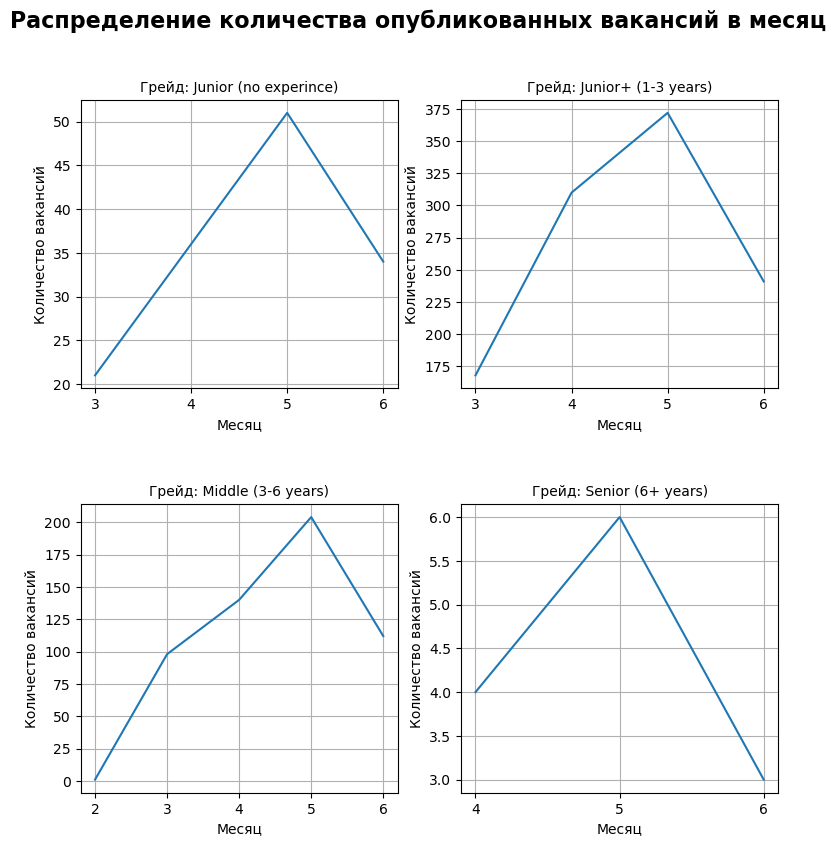

In [417]:
plt.figure(figsize=[9, 9])
plt. suptitle('Распределение количества опубликованных вакансий в месяц', fontsize=16, fontweight='bold')
plt.subplots_adjust(hspace=0.4)
i = 1
for t in vacancies_da['experience'].unique():
    
    
    data_month = vacancies_da[vacancies_da['experience']==t].pivot_table(index='month', values='name',aggfunc='count')
    data_month.columns = ['v_count']
    data_month.reset_index(inplace=True)

    plt.subplot(2,2,i)
    plt.title('Грейд: '+t, fontsize=10)
    plt.plot(data_month['month'],data_month['v_count'])
    plt.grid()
    
    plt.xticks(np.arange(min(data_month['month']), max(data_month['month'])+1, 1.0))
    i+=1


    
    plt.xlabel('Месяц');
    plt.ylabel('Количество вакансий');

Мы видим, что каждый месяц количество опубликованных вакансий растет для аналитиков данных вне зависимости от грейда. Так как данные за июнь у нас неполные (только за 11 дней), то спад в июне не стоит рассматривать.

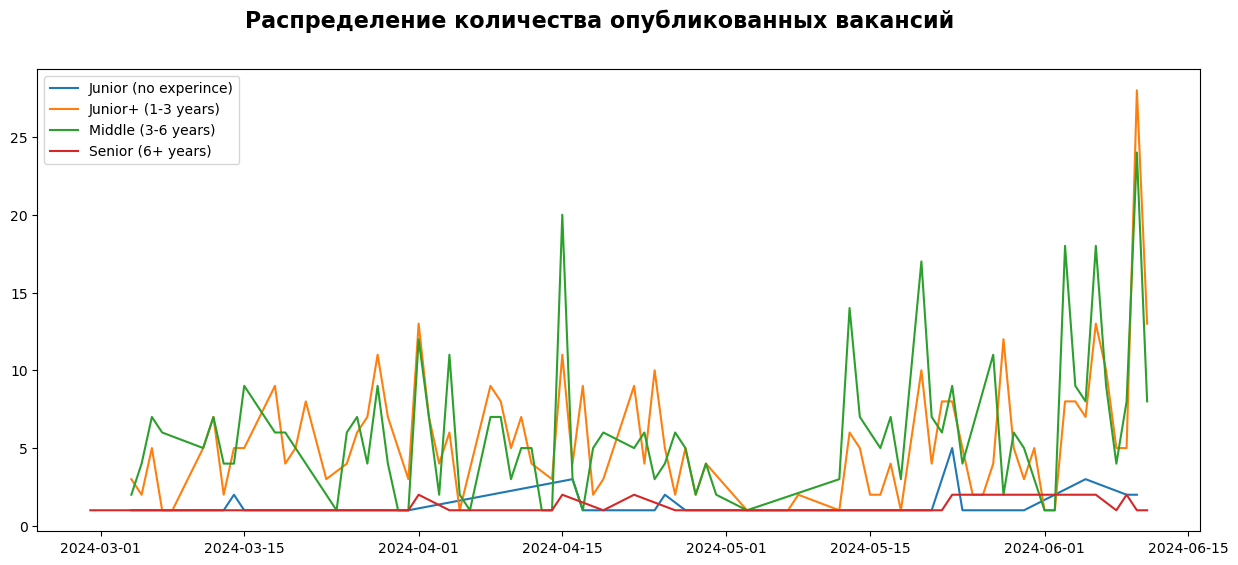

In [421]:
plt.figure(figsize=[15, 6])
plt. suptitle('Распределение количества опубликованных вакансий', fontsize=16, fontweight='bold')

for t in vacancies_ds['experience'].unique():
    vacancies_ds['date'] = pd.to_datetime(vacancies_ds['published_at']).dt.date
    plt.plot(vacancies_ds[vacancies_ds['experience']==t].groupby('date')['id'].count(), label=t)
    plt.legend()
  

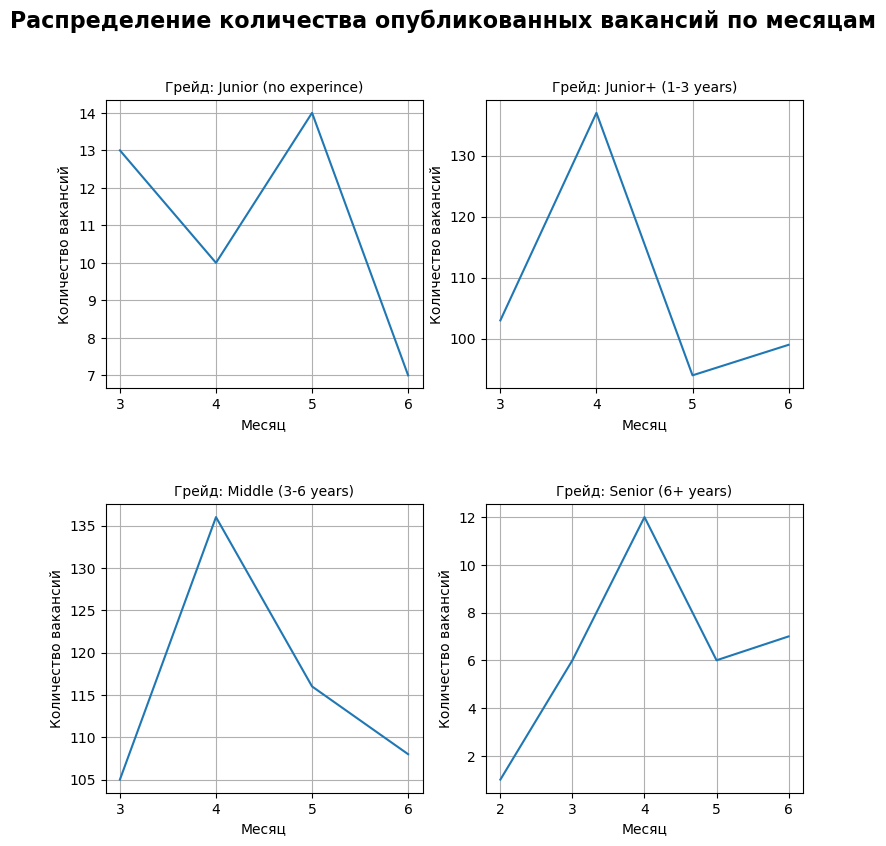

In [363]:
# fig, axs = plt.subplots(nrows= 4 , ncols= 1 )

plt.figure(figsize=[9, 9])
plt. suptitle('Распределение количества опубликованных вакансий по месяцам', fontsize=16, fontweight='bold')
plt.subplots_adjust(hspace=0.4)
i = 1
for t in vacancies_ds['experience'].unique():

    data_month = vacancies_ds[vacancies_ds['experience']==t].pivot_table(index='month', values='name',aggfunc='count')
    data_month.columns = ['v_count']
    data_month.reset_index(inplace=True)

    plt.subplot(2,2,i)
    plt.title('Грейд: '+t, fontsize=10)
    plt.plot(data_month['month'],data_month['v_count'])
    plt.grid()
    #plt.xlim(2, 6)
    plt.xticks(np.arange(min(data_month['month']), max(data_month['month'])+1, 1.0))
    i+=1

    plt.xlabel('Месяц');
    plt.ylabel('Количество вакансий');

У специалистов data science нет такой стабильности в динамике, например, в апреле публиковалось наибольшее количество вакансий, особенно требовались специалисты уровня Junior+, Middle и Senior, однако в мае они требовались гораздо меньше, а вот Junior специалисты нужны были больше всего в мае.

## Выводы

Нам были даны два файла с информацией о вакансиях аналитиков данных и специалистов data science, опубликованных в период февраль - июнь 2024 года на сайте hh.ru.

В ходе анализа полученных данных можно сделать следующие выводы:
* в заданный период вакансий аналитиков было опубликовано почти в два раза больше, чем вакансий data science, что означает, что аналитикам предоставляется больший выбор вакансий;
* в ходе предобработки данных были максимально заполнены пропуски, оставили только пропуски в столбцах `salary_from` и `salary_to`, так как заполнение пропусков в них сдвинет и среднее и медианное значение;
* При подготовке данных к анализу было выявлено большое количество дубликатов вакансий как у аналитиков, так и у специалистов data science. Так как размещение вакансий является платной услугой со сроком размещения 30 дней, то вакансии размещаются не по ошибке, поэтому дубликатами мы такие вакансии считать не будем и поэтому удалять их из данных тоже не стали;
* аналитикам данных платят меньше, чем специалистам data science, при этом есть прямая зависимость между нижней и верхней границей предлагаемых зарплат;
* на должность аналитика данных чаще всего требуются люди с опытом работы 1-3 года, а на должность специалиста data science больше всего требуются люди с более богатым опытом работы 3-6 лет, специалистов без опыта работы чаще ищут на должность аналитика, в то время как людей с опытом более 6 лет - на должность специалиста data science;
* Сбер и его подразделения - самый крупный работодатель, как для аналитиков, так и для специалистов data science, для специалистов уровня Junior, Junior+ и Middle. Также таких специалистов ищут маркетплейсы, банки, сети магазинов. Специалистов уровня Senior ищут гораздо меньше компаний, возможно, это всязано с внутренним рекрутингом и вертикальным ростом;
* аналитикам данных в среднем платят от 70 000 до 210 000 рублей в зависимости от грейда, специалистам data science - от 75 000 до 260 000 рублей в зависимости от грейда, однако, в среднем специалисты уровня Middle являются самыми высокооплачиваемыми. Скорее всего это связано с тем, что многие работодатели при публикации вакансии не указывают уровень заработной платы, которая будет отдельно обговариваться при собеседовании с успешными кандидатами. Во-первых, это позволяет не указывать конкурентам уровень зарплат в компании, и сохраняется коммерческая тайна. Во-вторых, при приеме нескольких кандидатов на одну и ту же должность можно договориться на разные заработные платы, таким образом съэкономив бюджет зарплат;
* Работодатели в основном предлагают трудовой договор на полный рабочий день, удаленную работу предлагают только 20% работодателей. Для специалистов без опыта работы есть возможность попасть на стажировку в компанию;
* Таким образом типичное место работы
1. аналитика:
    1.1. Junior аналитик работает в Сбере (и его подразделениях) или сети магазинов в офисе полный рабочий день с зарплатой от 64000 до 73000 рублей;
    1.2. аналитик Junior+ также работает в Сбере в офисе полный рабочий день с зарплатой от 98000 до 130000 рублей;
    1.3. Middle аналитик в качестве места работы может выбрать Сбер или маркетплейс или банк, работает полный день из офиса (75% случаев ) или удаленно (25% ) и получает от 175000 до 245000 рублей;
    1.4. аналитик Senior получает за свой труд от 155000 до 240000 рублей, работая полный рабочий день, чаще из офиса, чем удаленно, но не сильно больше, работает в крупных компаниях, сетях магазинов.
2. специалисты data science:
    2.1. Junior специалист получает от 73000 до 77000 рублей, работая в Сбере полный день;
    2.2. Junior+ работает в СБере, получает от 124000 до 230000 рублей;
    2.3. Middle специалист в Сбере или маркетплейсе получает от 214000 до 309000 рублей;
    2.4. Senior работает в крупных международных компаниях, получает от 160000 до 345000 рублей.
* При приеме на работу работодателей больше интересуют hard скиллы кандидатов, причем специалистам data science они важнее, а вот soft скиллы больше нужны аналитикам данных и senior специалистам data science;
* Если посмотреть какие именно скиллы нужны кандидатам, то аналитикам данных на любом уровне важно знать Python и Pandas в частности, SQL, специалистам грейда Junior также важно уметь работать с Excel, а вот для Middle и Senior - в большей степени уметь анализировать данные. Из soft скиллов важно иметь аналитическое мышление, уметь работать с документацией и большими объемами информации и быть коммуникабельными.
У специалистов data science картина несколько другая: важны Python и Pandas в частности, SQL и Machine Learning, Junor специалисты должны знать математическую статистику. Из soft скиллов можно выделить как самые важные - работа с документацией и коммуникабельность, а также иметь аналитическое мышление.

* Каждый месяц количество опубликованных вакансий растет для аналитиков данных вне зависимости от грейда. Так как данные за июнь у нас неполные (только за 11 дней), то спад в июне не стоит рассматривать. У специалистов data science нет такой стабильности в динамике, например, в апреле публиковалось наибольшее количество вакансий, особенно требовались специалисты уровня Junior+, Middle и Senior, однако в мае они требовались гораздо меньше, а вот Junior специалисты нужны были больше всего в мае.

Ссылка на презентацию:https://docs.google.com/presentation/d/1sM4LYFgOl4lRYcSN_n-0TyerOu3nb7Fe/edit?usp=sharing&ouid=107826230984105387228&rtpof=true&sd=true